# Projet 3 - TechNova RH

---

Objectif : Face à un taux de démission particulièrement élevé en ce moment, besoin d'identifier les causes potentielles, ainsi que des leviers actionnables pour remédier à cela.

In [598]:
import sys

sys.path.append('/var/data/python/lib/python3.13/site-packages')

from imblearn.over_sampling import SMOTE
print("SMOTE imported testing")

SMOTE imported testing


# Analyse Exploratoire

In [599]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [600]:
pd.set_option('display.max_columns', None)
# Pour afficher toutes les lignes :
pd.set_option('display.max_rows', None)

In [601]:
eval = pd.read_csv("extrait_eval.csv")
sirh = pd.read_csv("extrait_sirh.csv")
sondage = pd.read_csv("extrait_sondage.csv")

## Base de données 1 :  **Employee Survey** 

Enquête annuelle sur le bien-être des employés, enrichie avec une variable indiquant si l’employé a quitté l’entreprise ou non.

In [602]:
sondage.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [603]:
sondage.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        1470 non-null   int64
dtypes: 

In [604]:
sondage.describe()

,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.793878,2.799320,1.0,1024.865306,9.192517,2.912925,2.187755,4.123129
std,0.852077,1.289271,0.0,602.024335,8.106864,1.024165,3.222430,3.568136
min,0.000000,0.000000,1.0,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,2.000000,1.0,491.250000,2.000000,2.000000,0.000000,2.000000
50%,1.000000,3.000000,1.0,1020.500000,7.000000,3.000000,1.000000,3.000000
75%,1.000000,3.000000,1.0,1555.750000,14.000000,4.000000,3.000000,7.000000
max,3.000000,6.000000,1.0,2068.000000,29.000000,5.000000,15.000000,17.000000


In [605]:
sondage["nombre_participation_pee"].value_counts()

nombre_participation_pee
0    631
1    596
2    158
3     85
Name: count, dtype: int64

PEE - plan d'epargne entreprise - nombre de participations a la PEE

In [606]:
sondage["nombre_employee_sous_responsabilite"].value_counts()

nombre_employee_sous_responsabilite
1    1470
Name: count, dtype: int64

Pour les colonnes categoriques, on regarde ce qui est dedans :

In [607]:
print(sondage.select_dtypes(include='object').nunique())

a_quitte_l_entreprise    2
domaine_etude            6
ayant_enfants            1
frequence_deplacement    3
dtype: int64


C:\Users\andre\AppData\Local\Temp\ipykernel_32368\3329424010.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(sondage.select_dtypes(include='object').nunique())


In [608]:
sondage.select_dtypes(include='object').describe()

C:\Users\andre\AppData\Local\Temp\ipykernel_32368\2540319459.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sondage.select_dtypes(include='object').describe()


,a_quitte_l_entreprise,domaine_etude,ayant_enfants,frequence_deplacement
count,1470,1470,1470,1470
unique,2,6,1,3
top,Non,Infra & Cloud,Y,Occasionnel
freq,1233,606,1470,1043


In [609]:
print(sondage["a_quitte_l_entreprise"].value_counts())
print(sondage["domaine_etude"].value_counts())
print(sondage["ayant_enfants"].value_counts())
print(sondage["frequence_deplacement"].value_counts())

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64
domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: int64
ayant_enfants
Y    1470
Name: count, dtype: int64
frequence_deplacement
Occasionnel    1043
Frequent        277
Aucun           150
Name: count, dtype: int64


In [610]:
sondage.duplicated().sum()

np.int64(0)

Sondage est un extrait d'un sondage annuel avec aucune duplicates et aucun valeurs null. De 12 colonnes, il y a 4 qui sont des categories qui vont etre transformees:

* Est-ce que la personne est toujours dans l'entreprise?
* C'est quoi son domaine d'etude ?
* Est-ce que la personne a des enfants? (Bon, ici, c'est 100% oui)
* Eest-ce que la personne fait des deplacements frequentes? 

## Base de données 2 : **Évaluations de performance**

Contient les résultats des évaluations annuelles de performance ainsi que les scores de satisfaction des employés.


In [611]:
eval.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


In [612]:
eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 9   augementation_salaire_precedente           1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 115.0 KB


In [613]:
eval.describe()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.721769,2.729932,2.063946,2.728571,2.712245,2.761224,3.153741
std,1.093082,0.711561,1.106940,1.102846,1.081209,0.706476,0.360824
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,3.000000
50%,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000
75%,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000
max,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000


In [614]:
eval.select_dtypes(include='object').nunique()

C:\Users\andre\AppData\Local\Temp\ipykernel_32368\2809222591.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  eval.select_dtypes(include='object').nunique()


eval_number                         1470
heure_supplementaires                  2
augementation_salaire_precedente      15
dtype: int64

In [615]:
print(eval["augementation_salaire_precedente"].value_counts())
print(eval["heure_supplementaires"].value_counts())

augementation_salaire_precedente
11 %    210
13 %    209
14 %    201
12 %    198
15 %    101
18 %     89
17 %     82
16 %     78
19 %     76
22 %     56
20 %     55
21 %     48
23 %     28
24 %     21
25 %     18
Name: count, dtype: int64
heure_supplementaires
Non    1054
Oui     416
Name: count, dtype: int64


In [616]:
eval.select_dtypes(include=['object', 'str']).describe()

,eval_number,heure_supplementaires,augementation_salaire_precedente
count,1470,1470,1470
unique,1470,2,15
top,E_1,Non,11 %
freq,1,1054,210


L'extrait evaluation de performance annuel est un base de donnees 100% complete, avec aucun valeurs nulls. On comprend que 6 de 9 colonnes sont numeriques
Quand on verifie les colonnes categoriques ("str"), il y a des identifiants par ligne, une percentage qui decrit l'augmentation salaire precedente, et une question close (oui/non).

* L'augmentation salaire precedente va etre le moins facile a redefinir.

## Base de données 3 **HRIS** : 
Contient les informations RH des employés (poste, âge, salaire, ancienneté, données socio-démographiques, etc.).


In [617]:
sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [618]:
sirh.describe()

,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000
mean,1024.865306,36.923810,6502.931293,2.693197,80.0,11.279592,7.008163,4.229252
std,602.024335,9.135373,4707.956783,2.498009,0.0,7.780782,6.126525,3.623137
min,1.000000,18.000000,1009.000000,0.000000,80.0,0.000000,0.000000,0.000000
25%,491.250000,30.000000,2911.000000,1.000000,80.0,6.000000,3.000000,2.000000
50%,1020.500000,36.000000,4919.000000,2.000000,80.0,10.000000,5.000000,3.000000
75%,1555.750000,43.000000,8379.000000,4.000000,80.0,15.000000,9.000000,7.000000
max,2068.000000,60.000000,19999.000000,9.000000,80.0,40.000000,40.000000,18.000000


In [619]:
sirh.select_dtypes(include='object').nunique()

C:\Users\andre\AppData\Local\Temp\ipykernel_32368\1550169369.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sirh.select_dtypes(include='object').nunique()


genre             2
statut_marital    3
departement       3
poste             9
dtype: int64

In [620]:
print(sirh["genre"].value_counts())
print(sirh["statut_marital"].value_counts())
print(sirh["departement"].value_counts())
print(sirh["poste"].value_counts())

genre
M    882
F    588
Name: count, dtype: int64
statut_marital
Marié(e)       673
Célibataire    470
Divorcé(e)     327
Name: count, dtype: int64
departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64
poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64


In [621]:
sirh.select_dtypes(include='object').describe()

C:\Users\andre\AppData\Local\Temp\ipykernel_32368\27602267.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sirh.select_dtypes(include='object').describe()


,genre,statut_marital,departement,poste
count,1470,1470,1470,1470
unique,2,3,3,9
top,M,Marié(e),Consulting,Cadre Commercial
freq,882,673,961,326


In [622]:
print(sondage.columns.tolist())
print(sirh.columns.tolist())
print(eval.columns.tolist())

['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']
['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']


In [623]:
for nom, df in [('sondage', sondage), ('sirh', sirh), ('eval', eval)]:
    print(f"\n--- {nom} ---")
    for col in df.columns:
        print(col)


--- sondage ---
a_quitte_l_entreprise
nombre_participation_pee
nb_formations_suivies
nombre_employee_sous_responsabilite
code_sondage
distance_domicile_travail
niveau_education
domaine_etude
ayant_enfants
frequence_deplacement
annees_depuis_la_derniere_promotion
annes_sous_responsable_actuel

--- sirh ---
id_employee
age
genre
revenu_mensuel
statut_marital
departement
poste
nombre_experiences_precedentes
nombre_heures_travailless
annee_experience_totale
annees_dans_l_entreprise
annees_dans_le_poste_actuel

--- eval ---
satisfaction_employee_environnement
note_evaluation_precedente
niveau_hierarchique_poste
satisfaction_employee_nature_travail
satisfaction_employee_equipe
satisfaction_employee_equilibre_pro_perso
eval_number
note_evaluation_actuelle
heure_supplementaires
augementation_salaire_precedente


Les colonnes permettant de réaliser des jointures entre les trois fichiers : 

In [624]:
print(sondage['code_sondage'].head())
print(sirh['id_employee'].head())
print(eval['eval_number'].head())

0    1
1    2
2    4
3    5
4    7
Name: code_sondage, dtype: int64
0    1
1    2
2    4
3    5
4    7
Name: id_employee, dtype: int64
0    E_1
1    E_2
2    E_4
3    E_5
4    E_7
Name: eval_number, dtype: str


In [625]:
# Normaliser le cle d'eval // cle de jointure // join data 
# "E_" prefix 

# Step 1 : true// false : est-ce que tous les lignes commencent avec "E_"
print(eval['eval_number'].str.startswith('E_').all())

# Car on sait qu'oui, on peut creer une nouvelle colonne
eval['id_employee'] = eval['eval_number'].str.replace('E_', '', regex=False).astype(int)
print(eval[['eval_number', 'id_employee']].head())

True
  eval_number  id_employee
0         E_1            1
1         E_2            2
2         E_4            4
3         E_5            5
4         E_7            7


Maintenant que nous avons ID la colonne partargée entre les trois base de données :

In [626]:
df = sirh.merge(sondage, left_on='id_employee', right_on='code_sondage', how='left') \
         .merge(eval,    on='id_employee', how='left')

Ayant donné qu'on a utilisé le SIRH comme une base pour notre base de données centrale (car ceci nous donne les informations sur les employées), le df centrale devrait avoir les mêmes lignes comme SIRH

In [627]:
print(f"SIRH rows:    {len(sirh)}")
print(f"Sondage rows: {len(sondage)}")
print(f"Eval rows:    {len(eval)}")
print(f"Central df:   {len(df)}") 

SIRH rows:    1470
Sondage rows: 1470
Eval rows:    1470
Central df:   1470


On checke pour les valeurs nulls et manquantes ici ! Car chaque ligne correspond à un salariee

In [628]:
print(df.isna().sum())
# Pour ceci, isna(), qui sur un dataframe, va retourner un nouveau dataframe où tous les cellules sont
#  des booleans qui indiquent si la cellule originale est manquante.
print ("---" * 50)
missing_pct = df.isna().mean() * 100
# missing_pct nous donne une série avec les percentages de valeurs manquantes.
missing_pct.sort_values(ascending=False)

id_employee                                  0
age                                          0
genre                                        0
revenu_mensuel                               0
statut_marital                               0
departement                                  0
poste                                        0
nombre_experiences_precedentes               0
nombre_heures_travailless                    0
annee_experience_totale                      0
annees_dans_l_entreprise                     0
annees_dans_le_poste_actuel                  0
a_quitte_l_entreprise                        0
nombre_participation_pee                     0
nb_formations_suivies                        0
nombre_employee_sous_responsabilite          0
code_sondage                                 0
distance_domicile_travail                    0
niveau_education                             0
domaine_etude                                0
ayant_enfants                                0
frequence_dep

id_employee                                  0.0
age                                          0.0
genre                                        0.0
revenu_mensuel                               0.0
statut_marital                               0.0
departement                                  0.0
poste                                        0.0
nombre_experiences_precedentes               0.0
nombre_heures_travailless                    0.0
annee_experience_totale                      0.0
annees_dans_l_entreprise                     0.0
annees_dans_le_poste_actuel                  0.0
a_quitte_l_entreprise                        0.0
nombre_participation_pee                     0.0
nb_formations_suivies                        0.0
nombre_employee_sous_responsabilite          0.0
code_sondage                                 0.0
distance_domicile_travail                    0.0
niveau_education                             0.0
domaine_etude                                0.0
ayant_enfants       

# Contrôle du DataFrame après jointure

In [629]:
print(df.shape)
print("-------" * 15)
print(df.dtypes)
print("-------" * 15)
print("Est-ce qu'il y a des doublons?", df.duplicated().sum())
print("-------" * 15)
print(df.head(2))

(1470, 34)
---------------------------------------------------------------------------------------------------------
id_employee                                  int64
age                                          int64
genre                                          str
revenu_mensuel                               int64
statut_marital                                 str
departement                                    str
poste                                          str
nombre_experiences_precedentes               int64
nombre_heures_travailless                    int64
annee_experience_totale                      int64
annees_dans_l_entreprise                     int64
annees_dans_le_poste_actuel                  int64
a_quitte_l_entreprise                          str
nombre_participation_pee                     int64
nb_formations_suivies                        int64
nombre_employee_sous_responsabilite          int64
code_sondage                                 int64
distance_domicil

# Sélection de la variable cible

## Variable cible : `a_quitte_l_entreprise`

La variable `a_quitte_l_entreprise` correspond à la cible de notre modèle de prédiction.  
Elle indique si un employé a quitté l’entreprise ou non.

### Distribution des classes

- **Non** : 1223 employés  
- **Oui** : 237 employés  

### Analyse préliminaire

On observe un déséquilibre de classes dans la variable cible :
- Environ **16 %** des employés ont quitté l’entreprise.
- Environ **84 %** sont restés.

Ce déséquilibre devra être pris en compte lors de l’entraînement du modèle, car il peut entraîner un biais vers la classe majoritaire (`Non`).

# Colonnes numériques

In [630]:
quantitative = df.select_dtypes(include='number').columns.tolist()
qualitative  = df.select_dtypes(include='object').columns.tolist()

print("Quantitative:", quantitative)
print("Qualitative: ", qualitative)

df[quantitative].describe()

Quantitative: ['id_employee', 'age', 'revenu_mensuel', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle']
Qualitative:  ['genre', 'statut_marital', 'departement', 'poste', 'a_quitte_l_entreprise', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'eval_number', 'heure_supplementaires', 'augementation_salaire_precedente']


C:\Users\andre\AppData\Local\Temp\ipykernel_32368\2195615281.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  qualitative  = df.select_dtypes(include='object').columns.tolist()


,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,1024.865306,36.923810,6502.931293,2.693197,80.0,11.279592,7.008163,4.229252,0.793878,2.799320,1.0,1024.865306,9.192517,2.912925,2.187755,4.123129,2.721769,2.729932,2.063946,2.728571,2.712245,2.761224,3.153741
std,602.024335,9.135373,4707.956783,2.498009,0.0,7.780782,6.126525,3.623137,0.852077,1.289271,0.0,602.024335,8.106864,1.024165,3.222430,3.568136,1.093082,0.711561,1.106940,1.102846,1.081209,0.706476,0.360824
min,1.000000,18.000000,1009.000000,0.000000,80.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,491.250000,30.000000,2911.000000,1.000000,80.0,6.000000,3.000000,2.000000,0.000000,2.000000,1.0,491.250000,2.000000,2.000000,0.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,3.000000
50%,1020.500000,36.000000,4919.000000,2.000000,80.0,10.000000,5.000000,3.000000,1.000000,3.000000,1.0,1020.500000,7.000000,3.000000,1.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000
75%,1555.750000,43.000000,8379.000000,4.000000,80.0,15.000000,9.000000,7.000000,1.000000,3.000000,1.0,1555.750000,14.000000,4.000000,3.000000,7.000000,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000
max,2068.000000,60.000000,19999.000000,9.000000,80.0,40.000000,40.000000,18.000000,3.000000,6.000000,1.0,2068.000000,29.000000,5.000000,15.000000,17.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000


On comprend directement que :
* nombre_heures_travailless 
* nombre_employee_sous_responnsabilite

ont une deviation standard de 0. 

In [631]:
print(df['nombre_heures_travailless'].unique()) 
print(df['nombre_employee_sous_responsabilite'].unique())

[80]
[1]


Cela veut dire les deux colonnes peuvent etre supprimer comme elles nous donnent pas des informations nouvelles 

In [632]:
df = df.drop(columns=['nombre_heures_travailless', 'nombre_employee_sous_responsabilite'])


In [633]:
print((df['id_employee'] == df['code_sondage']).all())

True


Pourquoi nous avons ici deux colonnes avec les memes informations ? Ceci n'est pas etonnante car on avait join sur les memes employee ID's. Neanmoins, nous supprimons un des deux.

In [634]:
df = df.drop(columns=['code_sondage', 'id_employee'])


On remarque également que certaines colonnes sont en réalité des catégories ordonnées, mais qu'elles ont été encodées sous forme de nombres entiers :

- `niveau_education`
- `niveau_hierarchique_poste`
- `satisfaction_employee_environnement`
- `satisfaction_employee_nature_travail`
- `satisfaction_employee_equipe`
- `satisfaction_employee_equilibre_pro_perso`
- `note_evaluation_precedente`
- `note_evaluation_actuelle`

Par ailleurs, un détaille bien méritée de ntore attention - le dernier variable differe des autres, ayant un min valeur de 3.0 et non pas 1.0.

## Pd.Categorical()

Ces colonnes contiennent des valeurs numériques (1, 2, 3, 4...) mais elles représentent en réalité des niveaux ordonnés — par exemple "peu satisfait" à "très satisfait". On utilise Categorical pour indiquer à pandas que ces chiffres sont des rangs, et non des nombres sur lesquels on peut faire des calculs.

Ces colonnes ne sont ni des nombres (`int`), ni du texte (`str`) : ce sont des catégories ordonnées. 
On utilise `Categorical` pour indiquer à pandas que ces valeurs ont un ordre logique à respecter.

In [635]:
ordinal_cols = [
    'niveau_education',
    'niveau_hierarchique_poste',
    'satisfaction_employee_environnement',
    'satisfaction_employee_nature_travail',
    'satisfaction_employee_equipe',
    'satisfaction_employee_equilibre_pro_perso',
    'note_evaluation_precedente',
    'note_evaluation_actuelle'
]

for col in ordinal_cols:
    df[col] = pd.Categorical(df[col], ordered=True)

Nous allons verifier la changement de types de ces colonnes : 

In [636]:
print(df.dtypes)

age                                             int64
genre                                             str
revenu_mensuel                                  int64
statut_marital                                    str
departement                                       str
poste                                             str
nombre_experiences_precedentes                  int64
annee_experience_totale                         int64
annees_dans_l_entreprise                        int64
annees_dans_le_poste_actuel                     int64
a_quitte_l_entreprise                             str
nombre_participation_pee                        int64
nb_formations_suivies                           int64
distance_domicile_travail                       int64
niveau_education                             category
domaine_etude                                     str
ayant_enfants                                     str
frequence_deplacement                             str
annees_depuis_la_derniere_pr

In [637]:
numeriques = df.select_dtypes(include='int64').columns.tolist()
print(numeriques)

['age', 'revenu_mensuel', 'nombre_experiences_precedentes', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'nombre_participation_pee', 'nb_formations_suivies', 'distance_domicile_travail', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


# Colonnes catégoriques :

In [638]:
str_cols = df.select_dtypes('object')
print(str_cols.columns.tolist())

['genre', 'statut_marital', 'departement', 'poste', 'a_quitte_l_entreprise', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'eval_number', 'heure_supplementaires', 'augementation_salaire_precedente']


C:\Users\andre\AppData\Local\Temp\ipykernel_32368\1963324838.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes('object')


In [639]:
# Pour comprendre ce qui est dans chaque colonne qui reste toujours "str"

df = df.drop(columns=['eval_number']) # dropper car c'est un doublon de "id"

In [640]:
for col in df.select_dtypes('object'):
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- genre ---
genre
M    882
F    588
Name: count, dtype: int64

--- statut_marital ---
statut_marital
Marié(e)       673
Célibataire    470
Divorcé(e)     327
Name: count, dtype: int64

--- departement ---
departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64

--- poste ---
poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64

--- a_quitte_l_entreprise ---
a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64

--- domaine_etude ---
domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: in

C:\Users\andre\AppData\Local\Temp\ipykernel_32368\719899488.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes('object'):


* `ayant_enfants` : colonne inutile car Y 100%

In [641]:
df = df.drop(columns=['ayant_enfants'])

`augementation_salaire_precedente` : un nombre déguisé en texte ?
 à demander fernanda

`a_quitte_l_entreprise` : variable cible 

## Visualiser les colonnes numériques :

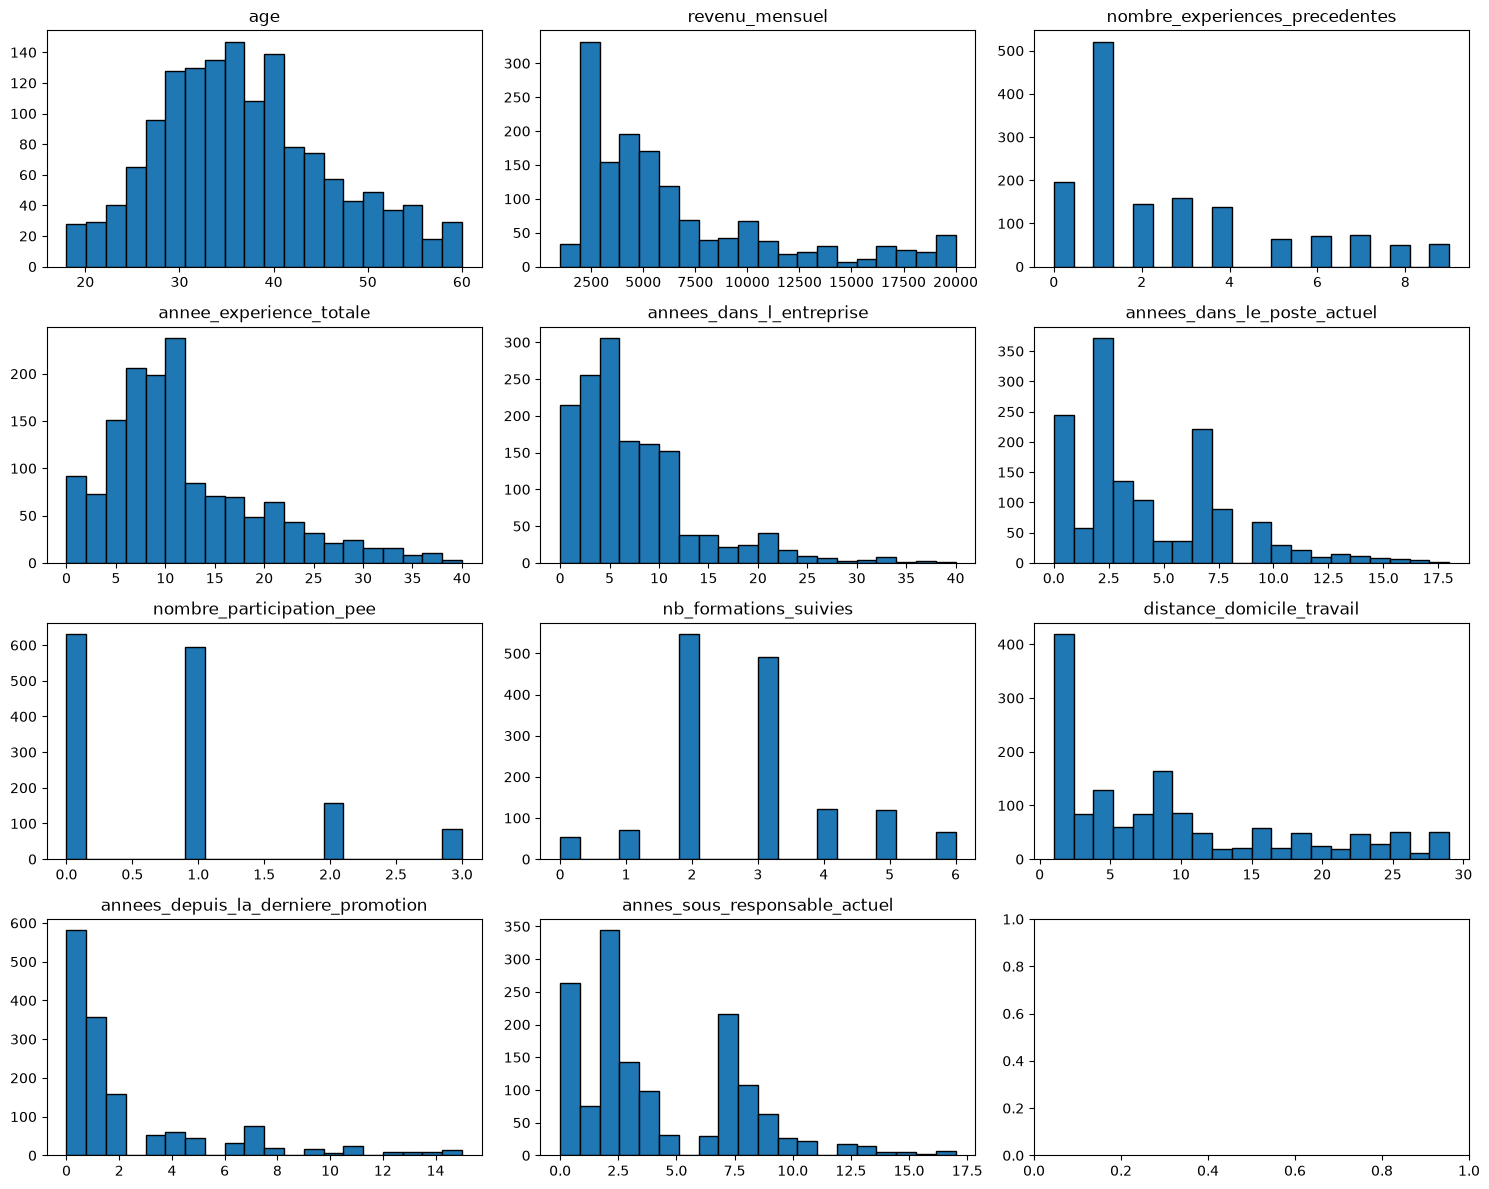

In [642]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeriques):
    axes[i].hist(df[col], bins=20, edgecolor='black')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Analyse des distributions des variables

## Observations générales

Les histogrammes montrent que plusieurs variables :

- présentent une asymétrie à droite (*right skewed*),
- sont discrètes (variables de comptage),
- contiennent potentiellement des valeurs extrêmes (*outliers*).

L’ensemble du dataset semble cohérent avec des données RH réelles :
- majorité d’employés en milieu de carrière,
- peu d’employés très seniors,
- distributions asymétriques classiques pour les revenus et l’ancienneté.

---

# Analyse variable par variable

## `id_employee`

La distribution est uniforme.

Cette variable correspond uniquement à un identifiant :
- elle n’a pas de valeur prédictive,
- elle devra être supprimée avant la modélisation.

## `age`
La distribution est en "bell-curve", plutôt centrée vers 30 et 40 qui nous donne un age moyenne pour la boîte.

## `revenu_mensuel` et `annees_dans_l_entreprise`

Les variables `revenu_mensuel` et `annees_dans_l_entreprise` semblent fortement liées : plus un employé reste longtemps dans l’entreprise, plus son revenu tend à augmenter. Cette relation suggère que l’entreprise valorise non seulement l’expérience professionnelle globale (`annee_experience_totale`), mais également l’ancienneté interne.

Cependant, très peu d’employés présentent une ancienneté supérieure à 10–15 ans. Cela peut indiquer une tendance générale à quitter l’entreprise après plusieurs années, traduisant potentiellement un niveau de turnover relativement élevé à long terme.

# Visualiser les categories

In [643]:
cat_cols = df.select_dtypes('object').columns.tolist()

C:\Users\andre\AppData\Local\Temp\ipykernel_32368\3982454930.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes('object').columns.tolist()


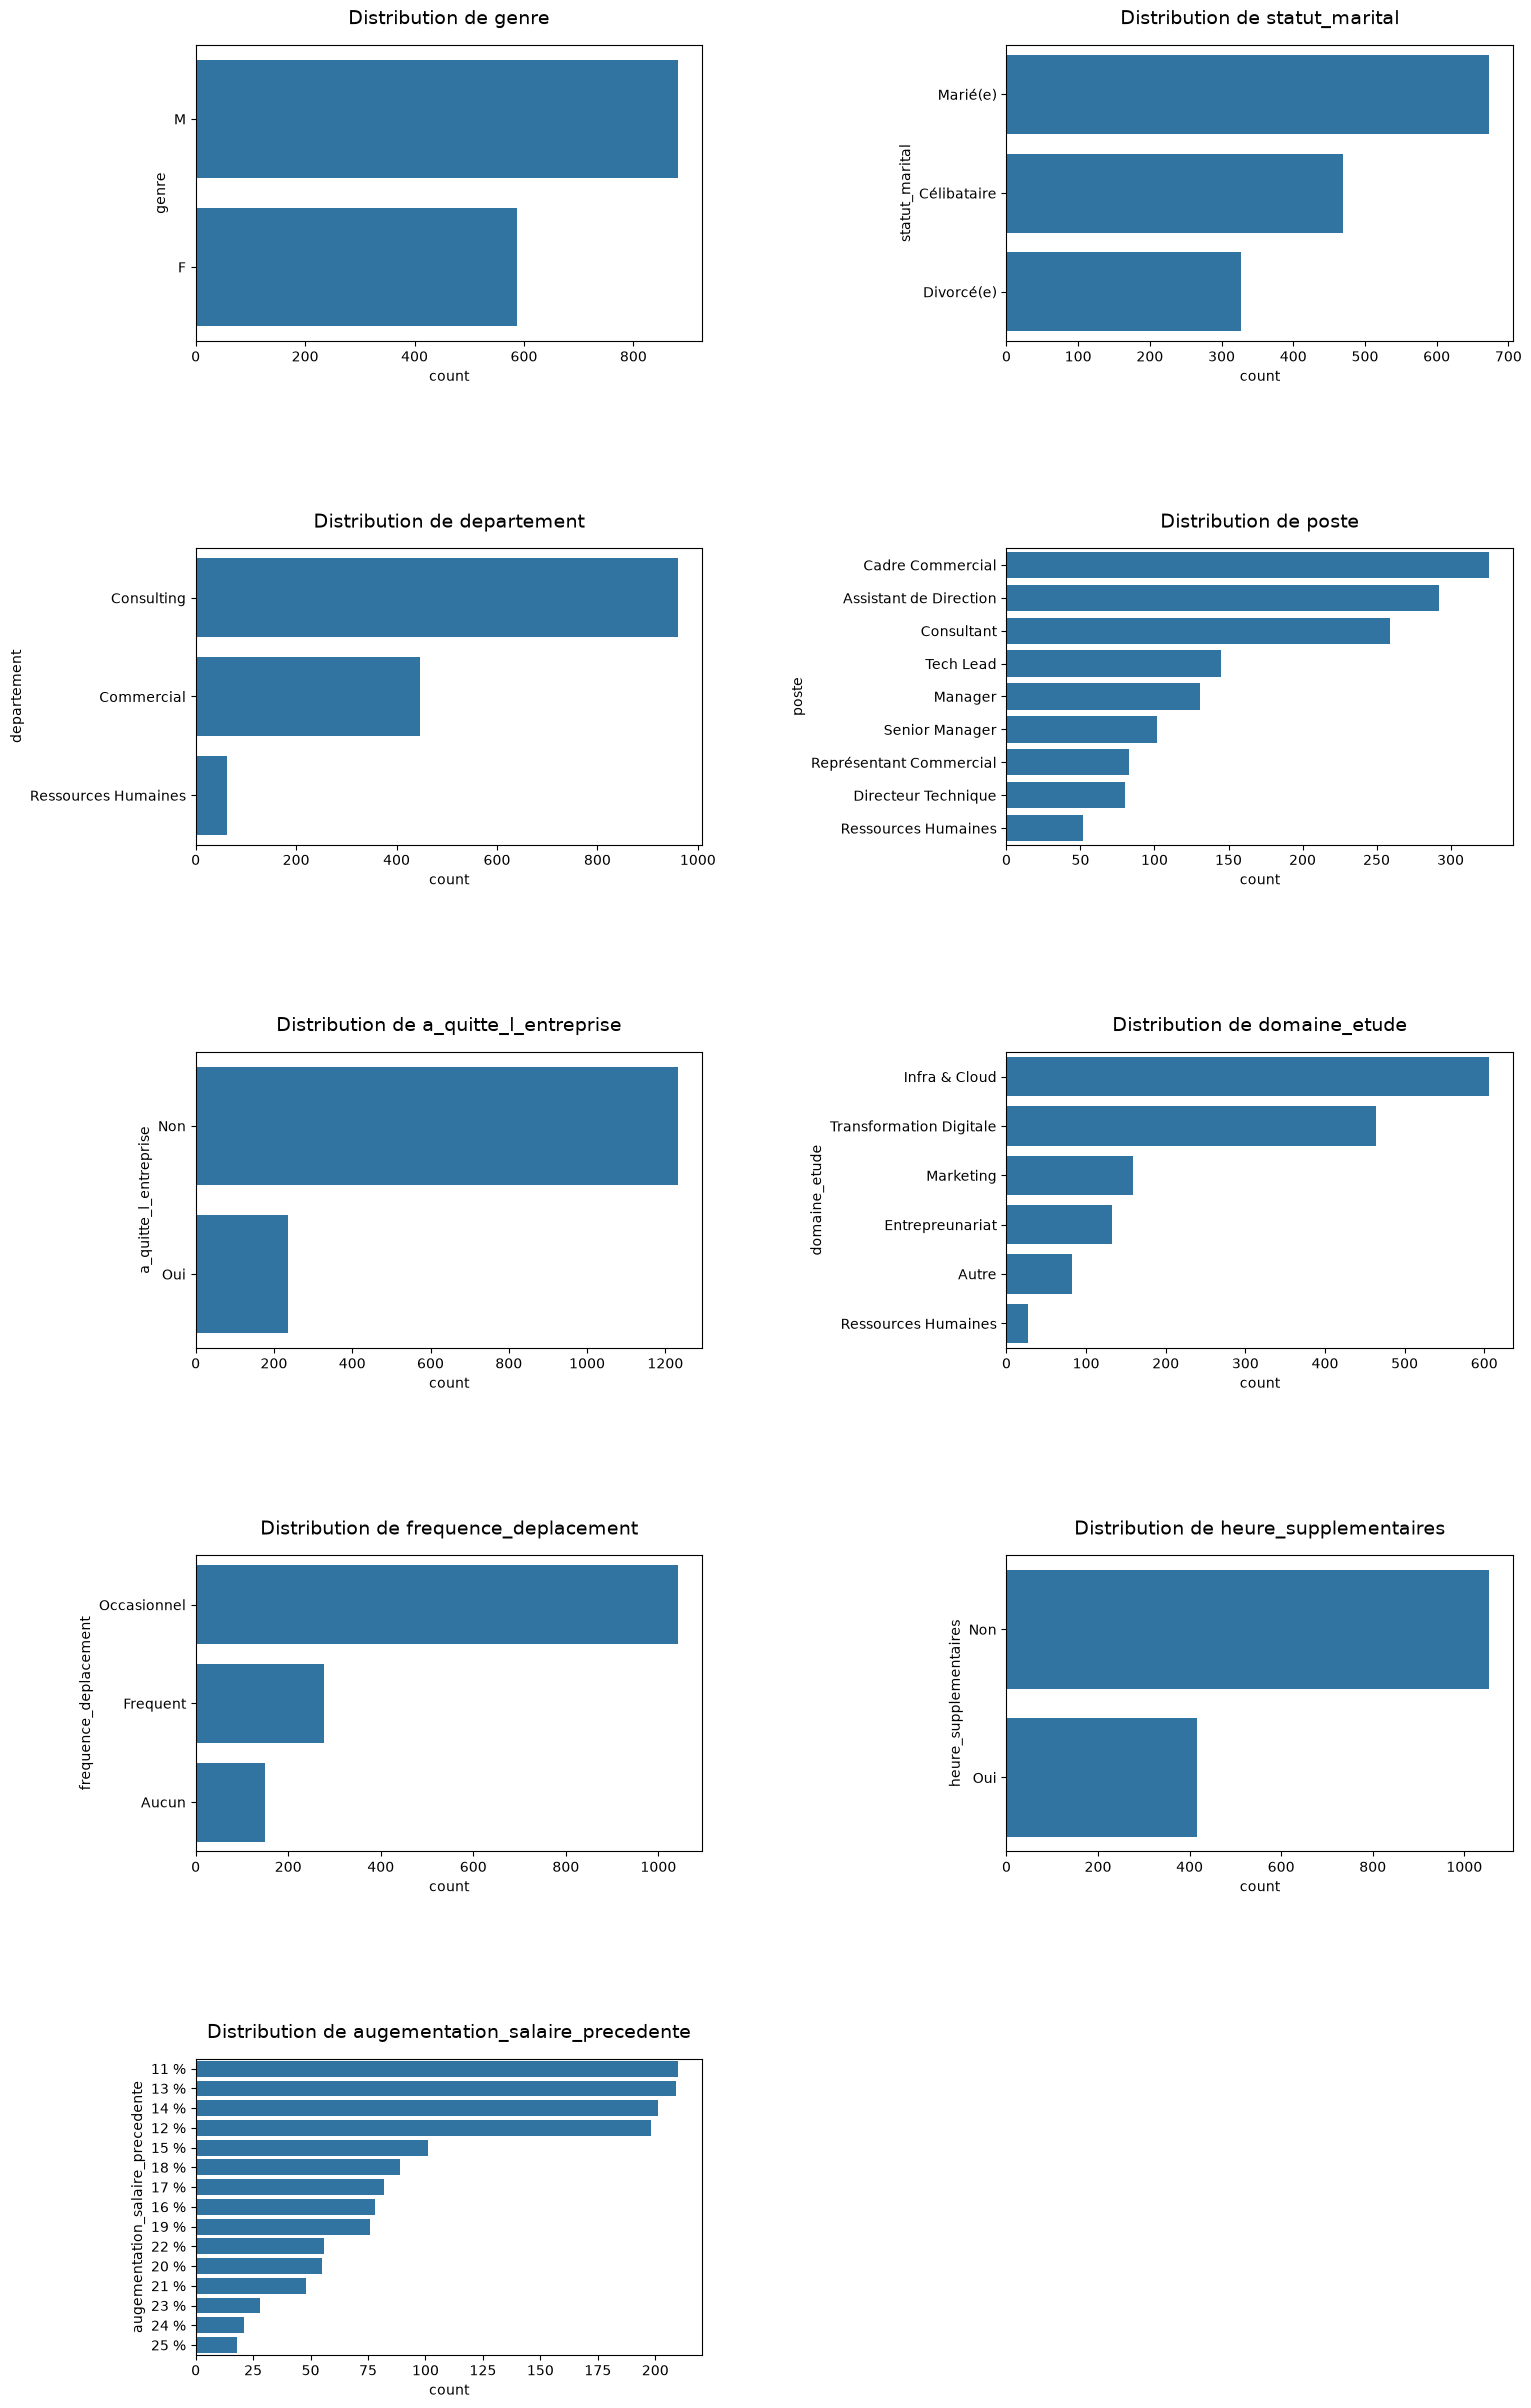

In [644]:
n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(17, 6 * n_rows))

for i, col in enumerate(cat_cols, 1):

    plt.subplot(n_rows, n_cols, i)

    sns.countplot(
        data=df,
        y=col,
        order=df[col].value_counts().index
    )

    plt.title(f"Distribution de {col}", fontsize=14, pad=15)
    # plt.xlabel("Nombre d'observations")
    plt.ylabel(col)

# Ajustement des espaces
plt.subplots_adjust(
    hspace=0.7,
    wspace=0.6
)

plt.show()

## Visualiser Cible x Numerique

En utilisant boxplot et KDE (Kernel Density Estimate - depits probability denisity at different values in a continuous variable), on voit et les outliers et la forme complete de chaque feature.

analyse bivariee

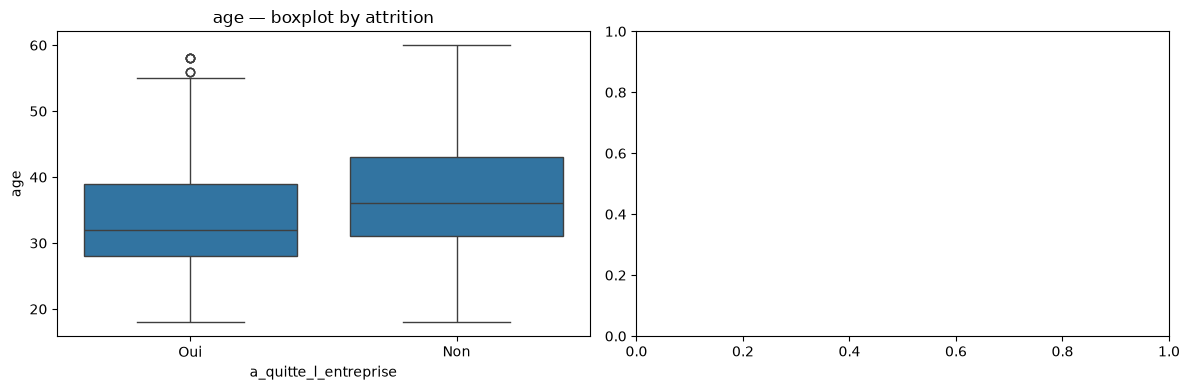

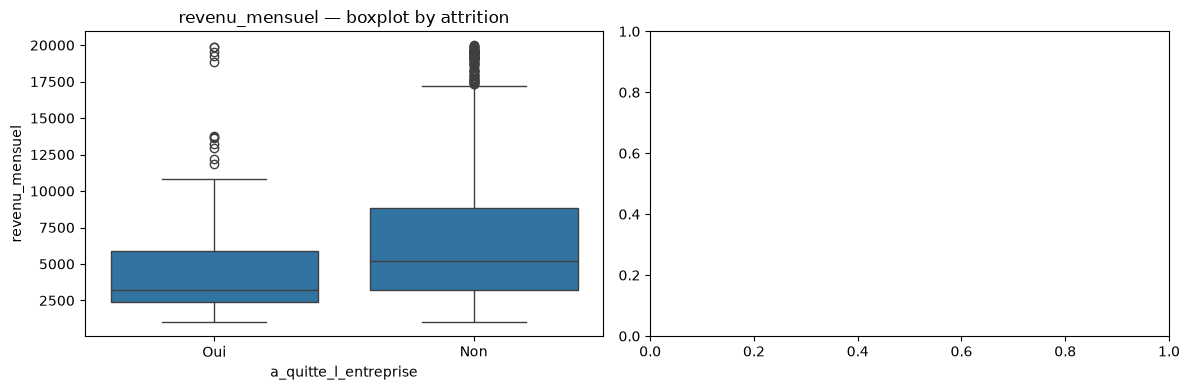

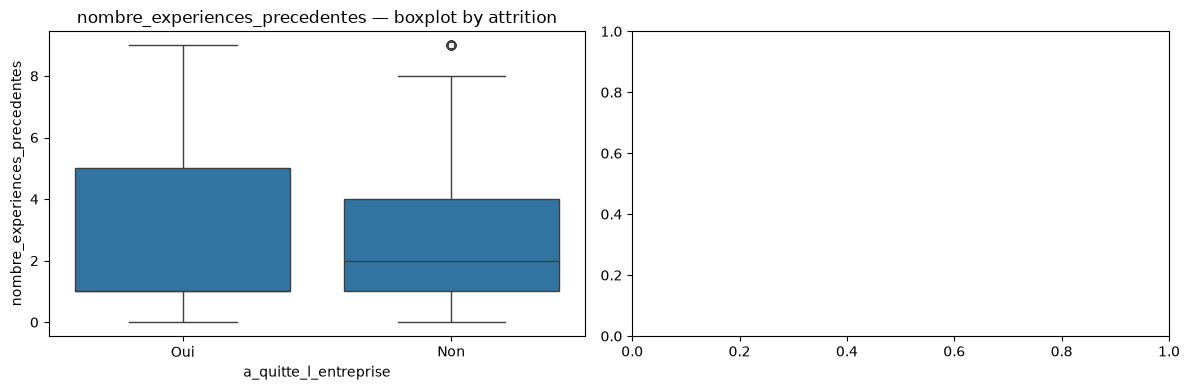

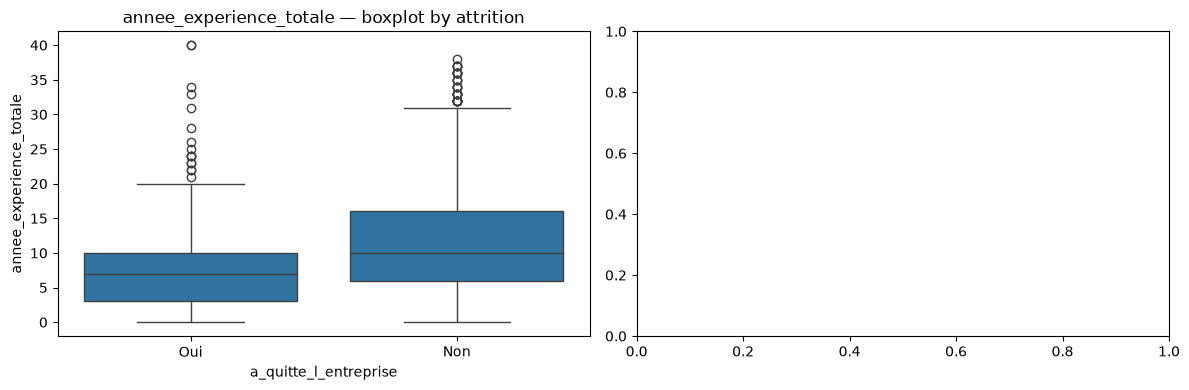

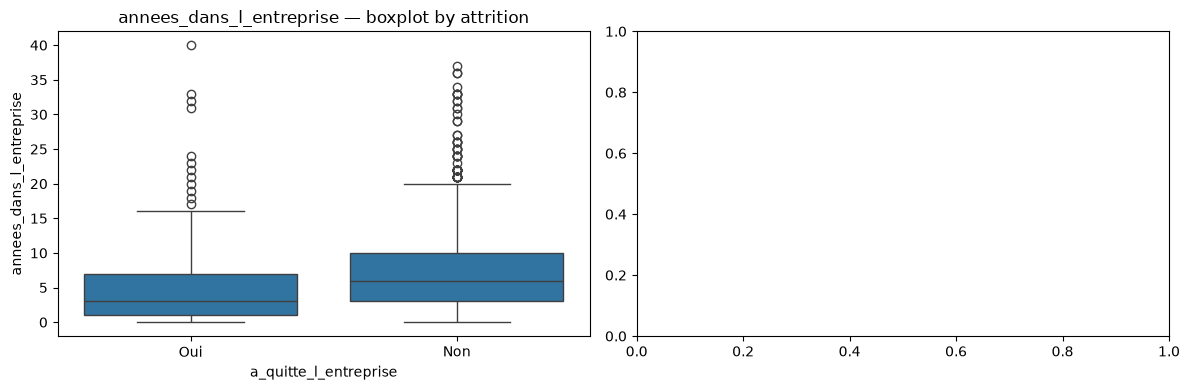

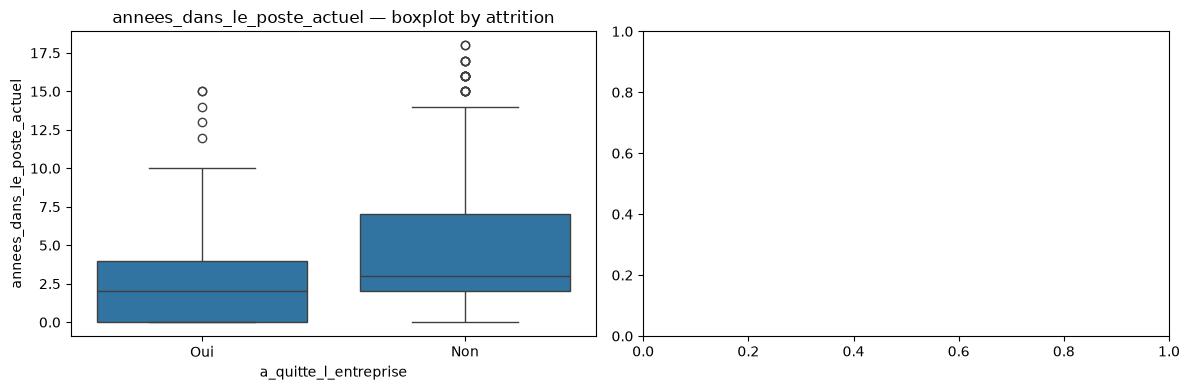

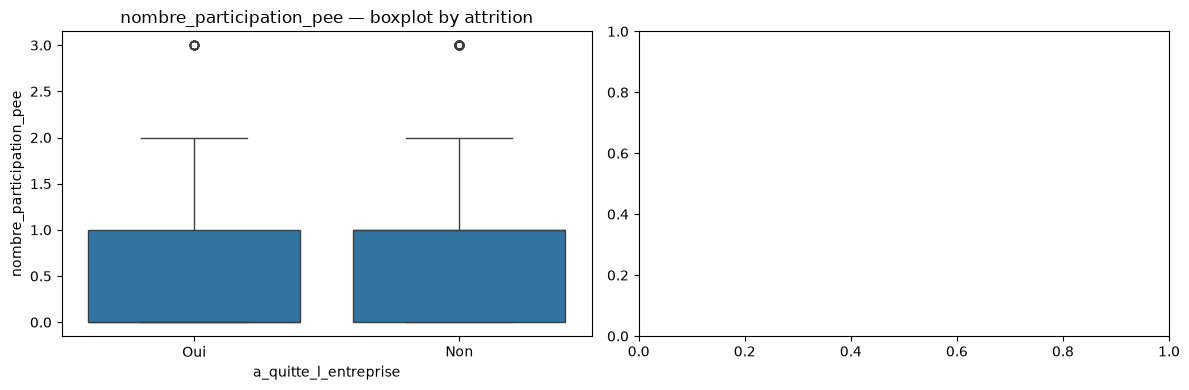

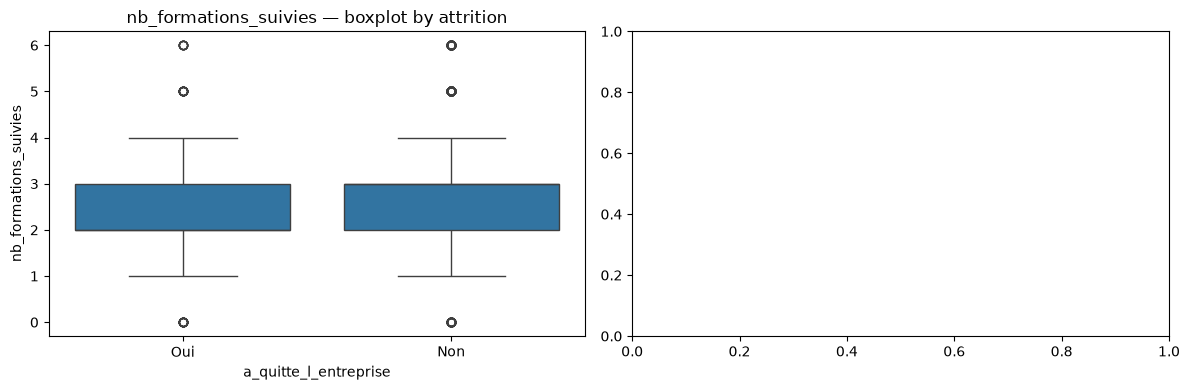

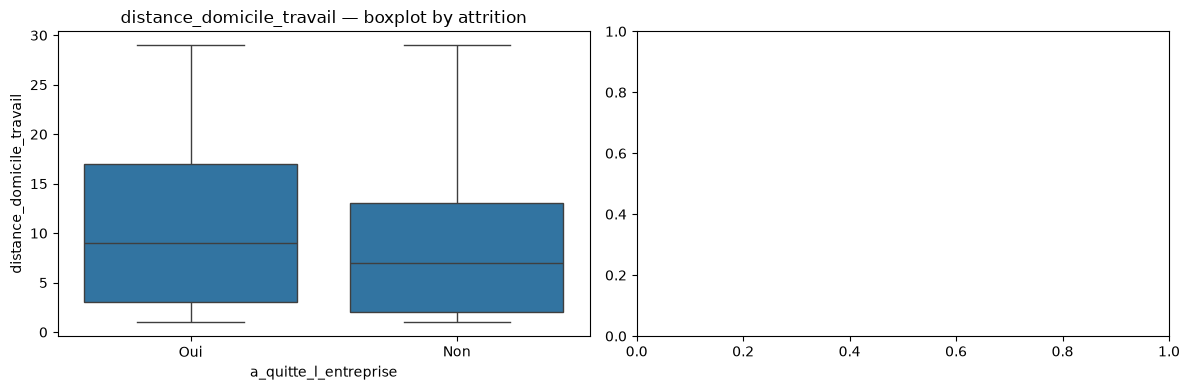

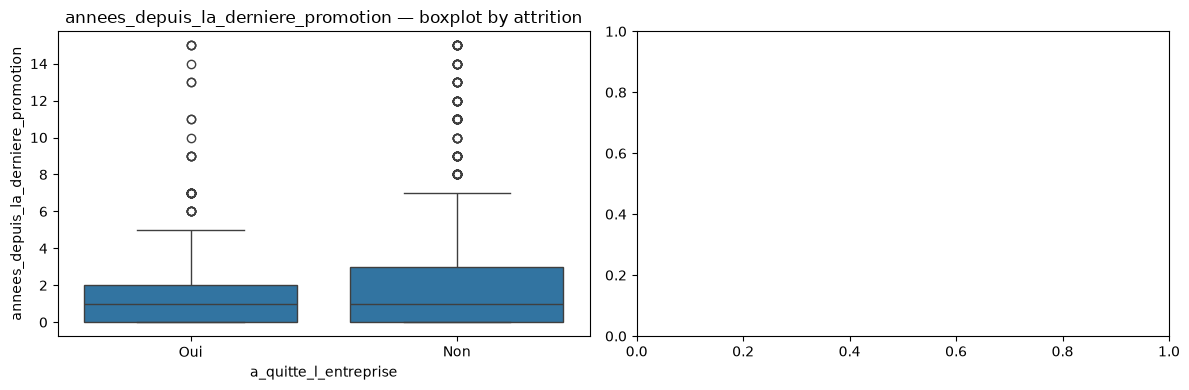

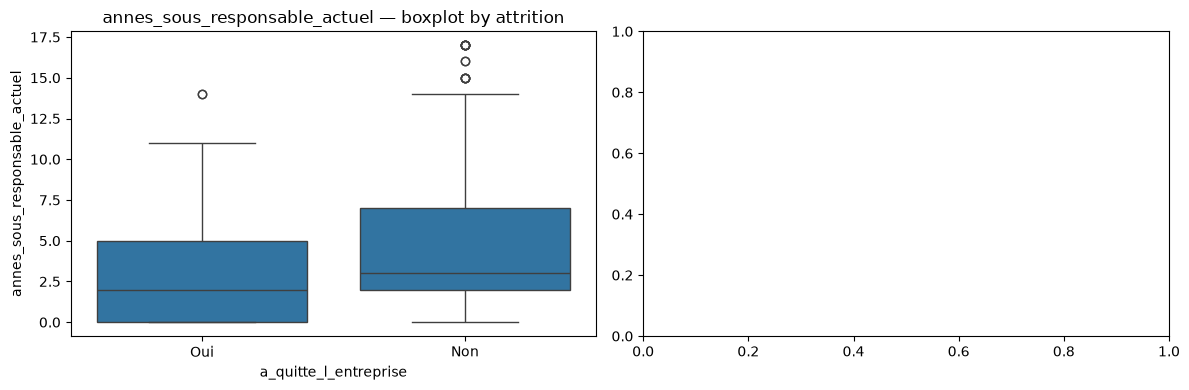

In [645]:
numerical_features = [col for col in numeriques if col != 'a_quitte_l_entreprise']

for col in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # boxplot: median + spread comparison et split by target so we get two curves on same plot - one for employees qui restent, et l'autre pour les gens qui partent
    sns.boxplot(data=df, x='a_quitte_l_entreprise', y=col, ax = axes[0])
    axes[0].set_title(f'{col} — boxplot by attrition')
    
    # KDE: full distribution shape per group
    # sns.kdeplot(data=df, x=col, hue='a_quitte_l_entreprise', fill=True, ax=axes[1])
    # axes[1].set_title(f'{col} — distribution by attrition')
    
    plt.tight_layout()
    plt.show()

* Quanti + Quanti → Scatter plot
* Quanti + Quali → Boxplot
* Quali + Quali → Bar chart

## Visualiser categories x cible

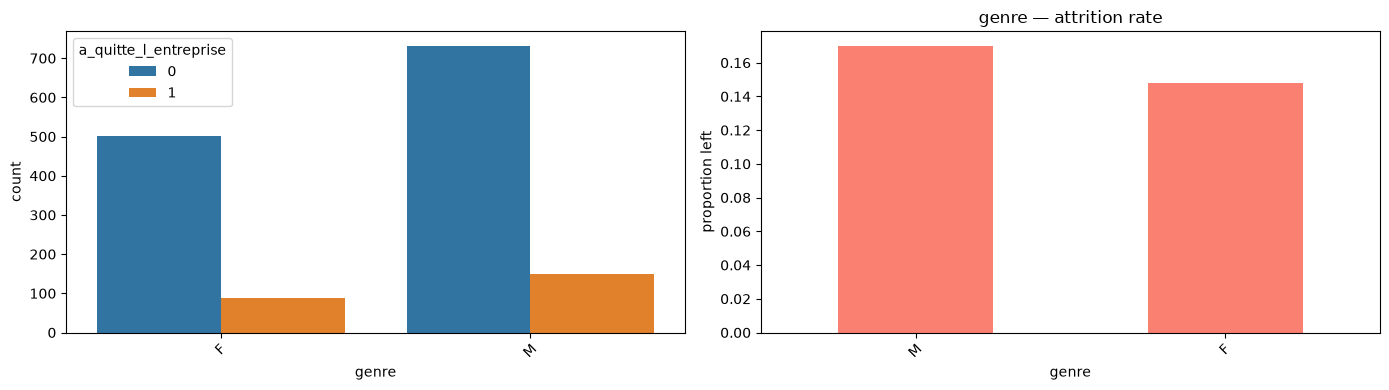

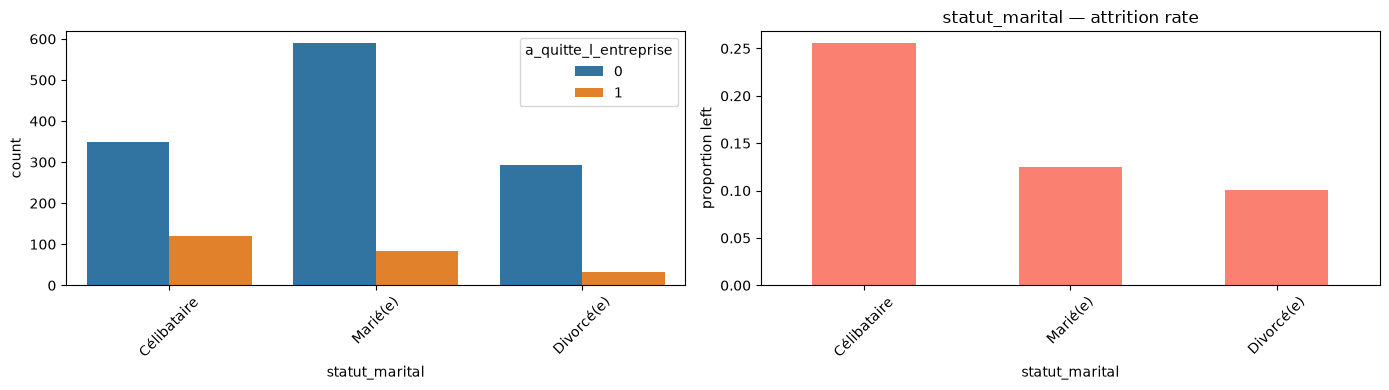

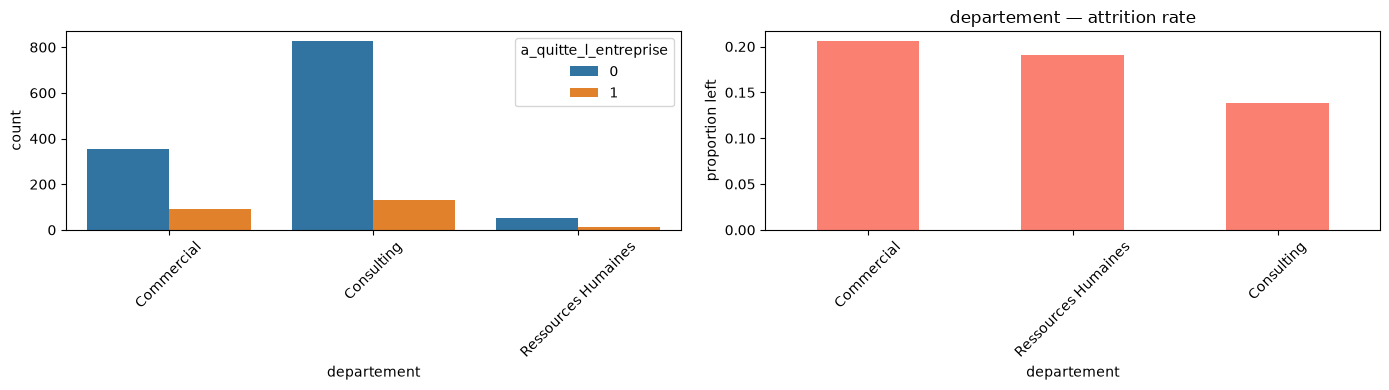

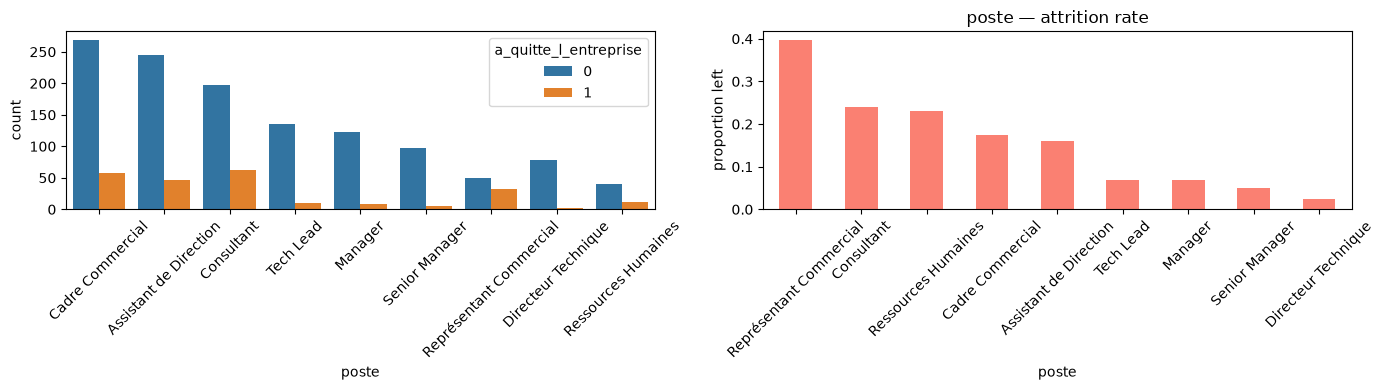

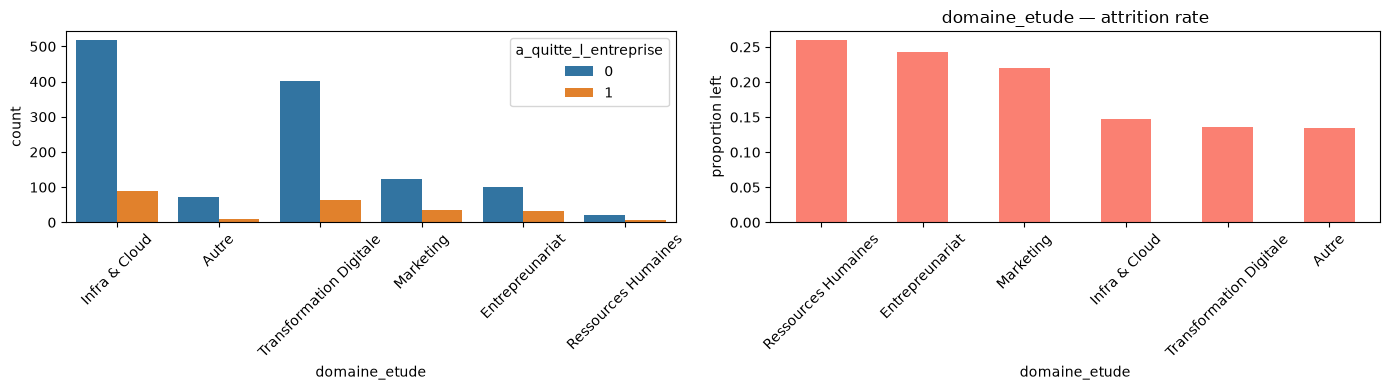

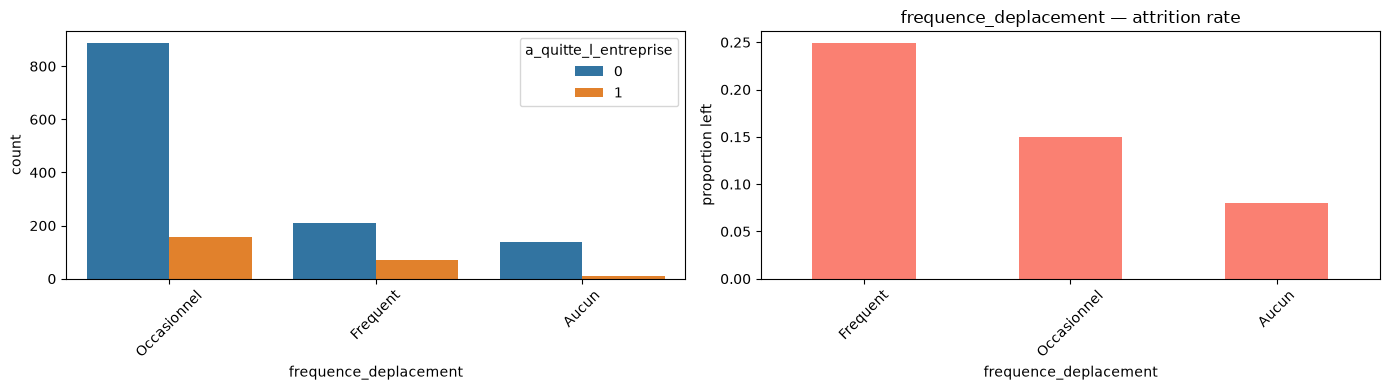

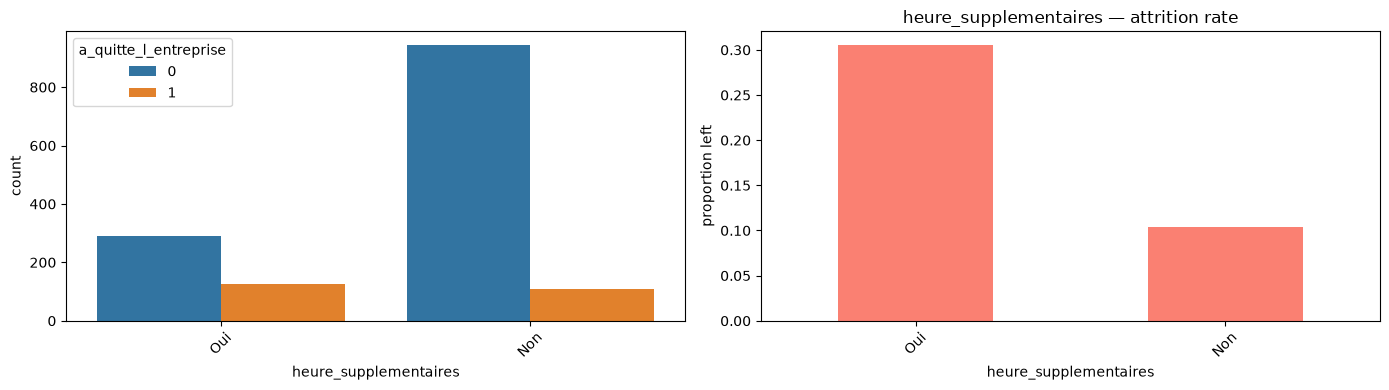

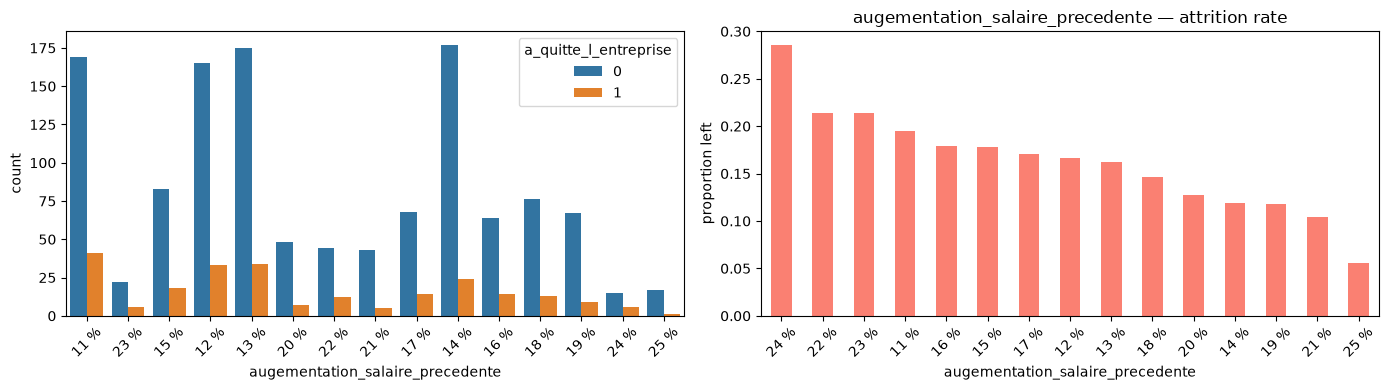

In [646]:
categorical_features = [col for col in cat_cols if col != 'a_quitte_l_entreprise']
df['a_quitte_l_entreprise'] = df['a_quitte_l_entreprise'].map({'Oui': 1, 'Non': 0})
# on change pour binaire ("oui -> 1", "non -> 0") afin de pouvoir visualiser

for col in categorical_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4)) # create figure with 1 row, two columns
    
    sns.countplot(data=df, x=col, hue='a_quitte_l_entreprise', ax =axes[0])
    axes[0].tick_params(axis='x', rotation=45)
    
    # attrition rate: proportion who left per category
    attrition_rate = df.groupby(col)['a_quitte_l_entreprise'].mean().sort_values(ascending=False)
    attrition_rate.plot(kind='bar', ax=axes[1], color='salmon')
    axes[1].set_title(f'{col} — attrition rate')
    axes[1].set_ylabel('proportion left')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## Correlation

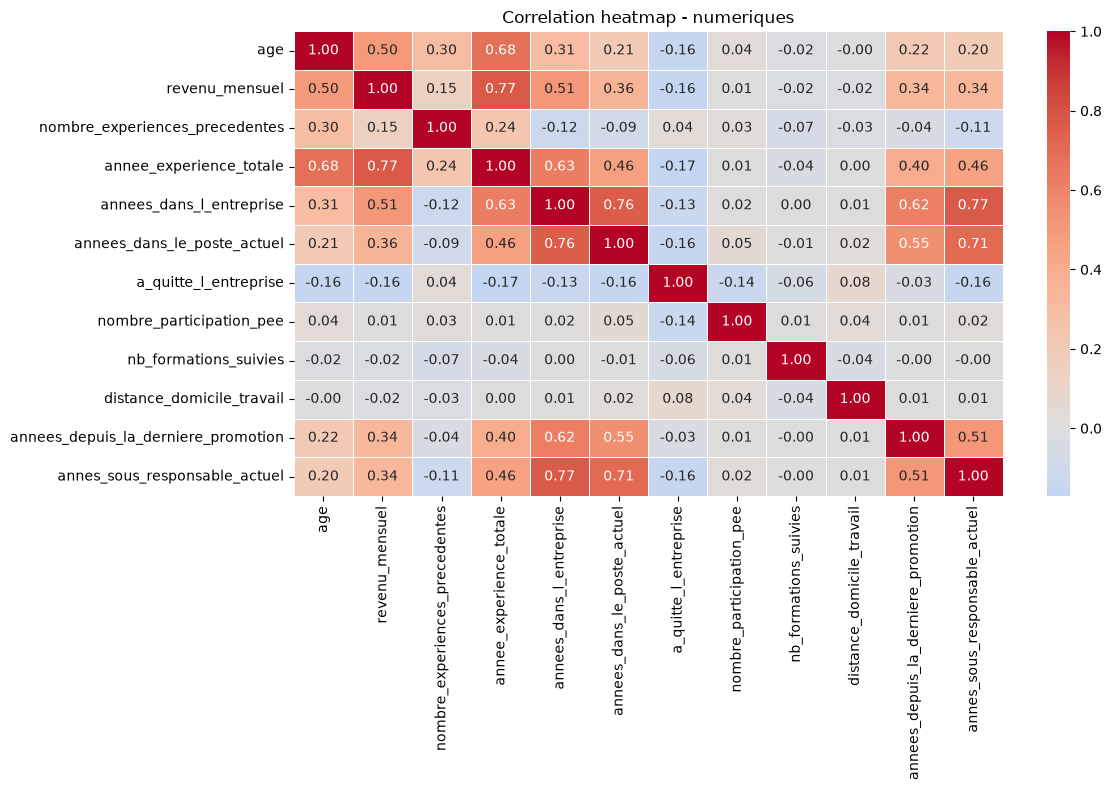

In [647]:
plt.figure(figsize=(12, 8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True, # show the numbers inside each cell
    fmt='.2f',
    cmap='coolwarm',
    center=0, 
    linewidths=0.5
)

plt.title('Correlation heatmap - numeriques')
plt.tight_layout()
plt.show()

In [648]:
df.describe()

,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,6502.931293,2.693197,11.279592,7.008163,4.229252,0.161224,0.793878,2.799320,9.192517,2.187755,4.123129
std,9.135373,4707.956783,2.498009,7.780782,6.126525,3.623137,0.367863,0.852077,1.289271,8.106864,3.222430,3.568136
min,18.000000,1009.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,2911.000000,1.000000,6.000000,3.000000,2.000000,0.000000,0.000000,2.000000,2.000000,0.000000,2.000000
50%,36.000000,4919.000000,2.000000,10.000000,5.000000,3.000000,0.000000,1.000000,3.000000,7.000000,1.000000,3.000000
75%,43.000000,8379.000000,4.000000,15.000000,9.000000,7.000000,0.000000,1.000000,3.000000,14.000000,3.000000,7.000000
max,60.000000,19999.000000,9.000000,40.000000,40.000000,18.000000,1.000000,3.000000,6.000000,29.000000,15.000000,17.000000


# Feature Engineering: 
Comprendre ce qu'on a pour transformer nos variables features.

## Ratio features

Career Loyalty Ratio : how much of their career has been here? Si bas, ils bougent beaucoup; si haut, ils sont ancres ici 

In [649]:
df['proportion_carriere_entreprise'] = (
    df['annees_dans_l_entreprise'] / (df['annee_experience_totale'] + 1)
)

Experience amene depuis outside:  
Est-ce que ces salaries sont venus au debut ou plus tard dans leur carriere ? 
-Meme si on pense pas car l'age moyenne des gens qui partents

In [650]:
df['experience_avant_entreprise'] = (
    df['annee_experience_totale'] - df['annees_dans_l_entreprise']
)

Est-ce qu'ils sont sous payees pour leurs experiences totales?

In [651]:
df['revenu_par_annee_experience'] = (
    df['revenu_mensuel'] / (df['annee_experience_totale'] + 1)
)

Est-ce que les salaires bouge du travail au travail beaucoup ? 
- s'ils ont historiquement des tenures petites, il y a une theme de depart qui n'est pas propre a la boite 

In [652]:
df['duree_moyenne_postes_precedents'] = (
    df['experience_avant_entreprise'] / (df['nombre_experiences_precedentes'] + 1)
)

### Signaux de stagnation
Ces flags sont pour signaler les salariees qui peuvent se sentir comme leur carriere a cette boite a plateau

In [653]:
df['taux_promotion'] = (
    df['annees_depuis_la_derniere_promotion'] / (df['annees_dans_l_entreprise'] + 1)
)

In [654]:
df['stagnation_poste'] = (
    df['annees_dans_le_poste_actuel'] / (df['annees_dans_l_entreprise'] + 1)
)

In [655]:
df['stagnation_poste'].value_counts()

stagnation_poste
0.000000    244
0.500000    201
0.666667    200
0.333333     78
0.875000     67
0.600000     59
0.777778     58
0.400000     56
0.636364     34
0.800000     33
0.700000     31
0.818182     31
0.727273     26
0.714286     26
0.285714     23
0.571429     19
0.750000     18
0.428571     13
0.250000      9
0.625000      8
0.272727      8
0.363636      8
0.833333      8
0.166667      8
0.181818      7
0.200000      7
0.857143      6
0.380952      6
0.583333      5
0.785714      5
0.692308      5
0.533333      5
0.222222      5
0.687500      4
0.846154      4
0.545455      4
0.125000      4
0.642857      4
0.368421      4
0.142857      4
0.444444      4
0.733333      4
0.260870      3
0.615385      3
0.812500      3
0.350000      3
0.722222      3
0.300000      3
0.318182      3
0.409091      3
0.684211      3
0.842105      3
0.437500      3
0.555556      3
0.450000      3
0.461538      2
0.866667      2
0.764706      2
0.529412      2
0.111111      2
0.588235      2
0.73913

### Commute

In [656]:
df['distance_domicile_travail'].describe()

count    1470.000000
mean        9.192517
std         8.106864
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max        29.000000
Name: distance_domicile_travail, dtype: float64

Binning distance for travel between work and domicile

In [657]:
df['zone_distance'] = pd.cut(
    df['distance_domicile_travail'],
    bins=[0, 5, 15, 30],
    labels=['proche', 'moyen', 'loin']
)

In [658]:
print(df['zone_distance'].value_counts(dropna=False))

zone_distance
proche    632
moyen     509
loin      329
Name: count, dtype: int64


In [659]:
df['jamais_promu'] = (df['annees_depuis_la_derniere_promotion'] == 0).astype(int)
df['aucune_formation'] = (df['nb_formations_suivies'] == 0).astype(int)
df['aucune_participation_pee'] = (df['nombre_participation_pee'] == 0).astype(int)

# La nouvelle correlation

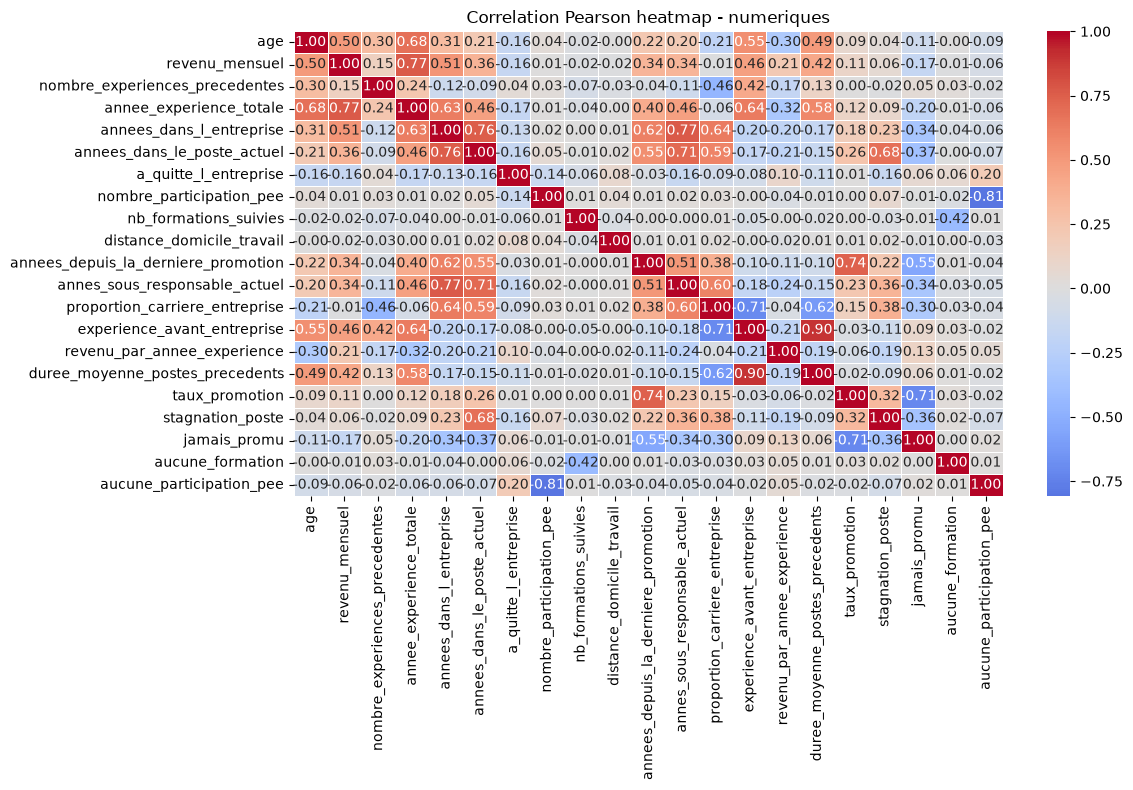

In [660]:
plt.figure(figsize=(12, 8))

corr_matrix = df.corr(numeric_only=True, method='pearson')

sns.heatmap(
    corr_matrix,
    annot=True, # show the numbers inside each cell
    fmt='.2f',
    cmap='coolwarm',
    center=0, 
    linewidths=0.5
)

plt.title('Correlation Pearson heatmap - numeriques')
plt.tight_layout()
plt.show()

# Préparer les données pour le modèle

Séparer X et y

In [661]:
X = df.drop(columns=['a_quitte_l_entreprise'])
y = df['a_quitte_l_entreprise']

Encoder les variables catégorielles restantes

In [662]:
X = pd.get_dummies(X, drop_first=True)

## La Stratification: 
L'un des principaux défis de ce jeu de données est le déséquilibre des classes (*class imbalance*). En effet, les observations ne sont pas réparties de manière homogène entre les différentes catégories.

Dans notre cas, la classe **"B" (Attrition)** ne représente qu'environ **16 %** des observations. Il s'agit donc d'une classe minoritaire.

Si nous entraînons un modèle et l'évaluons uniquement à l'aide de l'**accuracy** sur un jeu de données aussi déséquilibré, nous risquons d'obtenir des résultats trompeurs. Par exemple, un modèle pourrait prédire majoritairement la classe dominante et afficher une bonne accuracy tout en détectant très mal les cas d'attrition.

Pour éviter ce problème lors du découpage des données, nous utilisons l'option **`stratify=y`** dans `train_test_split()`. Cette approche garantit que la proportion de chaque classe est conservée dans les ensembles d'entraînement et de test, ce qui permet une évaluation plus représentative des performances du modèle.

In [663]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y #make sure that the split preserves the proportion of calsses
)

Nous pouvons vérifier si la stratification a fonctionné.

In [664]:
print("Train :", y_train.value_counts(normalize=True))
print("Test  :", y_test.value_counts(normalize=True))

Train : a_quitte_l_entreprise
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Test  : a_quitte_l_entreprise
0    0.840136
1    0.159864
Name: proportion, dtype: float64


Maintenant faut scaler les fonctionnalités numériques.

In [665]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit UNIQUEMENT sur train et non pas sur

Rappel : nous avons besoin de scaler, surtout pour certains modèles - notamment la Regression Logistique (notre premier modèle).

Chaque caractéristique a des échelles de mesures différentes, et si une variable a une valeur supérieure à celle des autres, elle dominera le calcul.

La mise à l'échelle met tout sur le même terrain de jeu : scaled_value = (value - medium) / standard_deviation

Chaque caractéristique se termine par une moyenne = 0 et un écart type = 1. Le modèle peut désormais comparer équitablement les caractéristiques.

Et aussi : nous fit seulement X_test afin de faire en sorte que scaler.transform (X_Test) va être appliqué sans réapplication (éviter les fuites de données)

# Comprendre Classification:

- On utilise la classification quand on veut catégoriser les données dans les classes différentes ou les groupes différents. L'output est un LABEL
- Les modèles de classification apprennent les limites de décision qui séparent une classe d'une autre. Utiliser des fonctions d'activation telles que SIGMOID pour la classification binaire afin de mapper les sorties entre 0 et 1 comme probabilité

# Les metrics :

* accuracy : (TP + TN/ Total)
    nous donne la proportion de les instances correctly classified
  
* precision : TP / (TP + FP)
    De tous les salaries que notre modele a predit partira, combien sont vraiment partis?

* recall : TP / (TP + FN)
    De tous les salaries qui sont vraiment partis, combien est-ce qu'on a pu capter?

* F1 score: 2 * (Precision x Recall / (Precision + Recall))

* AUC-ROC: Area Under Receving Operating Characteristic Curve: it plots the true positive rate against the false positive rate at various thresholds.


# Les modeles baseline (sans ajustement pour l'imbalance des classes)

<span style="font-size: 2.0em; font-weight: bold; color: #f6f6f6;">🧺 Modèle 0 : Dummy</span>
<br>


Pour notre Dummy, pour la modélisation régressive, nous avons utilisé un Dummy Regressor.
Aujourd'hui, nous utilisons le DummyClassifer comme une référence de prédire les moyennes ou les proportions, sans utiliser les fonctionnalités.

In [666]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(dummy.score(X_test, y_test))

0.8401360544217688


Ayant une balance des classes qui ne sont pas du tout équilibre, `most_frequent`
nous marquerons une précision de ~0.84. Cela nous démontre pourquoi la précision tout seule n'est pas adéquate.

In [667]:
# Helper function pour extraire Class 1 Minority :
def extract_minority_metrics(y_test, y_pred, y_proba):
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    minority_stats = report_dict['1']
    return { 
        'Precision' : round(minority_stats['precision'], 2),
        'Recall': round(minority_stats['recall'], 2),
        'F1-Score': round(minority_stats['f1-score'], 2),
        'AUROC': round(roc_auc_score(y_test, y_proba), 3),
        'AUPRC (Avg Prec)': round(average_precision_score(y_test, y_proba), 3)
    }

summary_data = {}

<span style="font-size: 2.0em; font-weight: bold; color: #f6f6f6;">📊 Modèle 1 : Régression Logistique</span>
<br>

La régression logistique est un modèle de classification, c'est-à-dire un algorithme d'apprentissage automatique supervisé. On donne nos caractéristiques (nos X colonnes), et pour chaque ligne, notre modèle produit une probabilité entre 0 et 1 : « quelle est la probabilité que cette ligne soit de classe 1 ?»

Il existe trois types de régression logistique :

- binomiale (lorsque la variable dépendante n'a que deux catégories possibles), multinomiale (lorsque la variable dépendante a trois catégories ou plus non ordonnées), et ordinale (utilisée lorsque les variables dépendantes)

- multinomiale : laquelle de ces catégories/réponses cibles ?

- binomiale : est-ce ceci ou est-ce cela ?

- ordinale : quel niveau ? Il y a plus de deux réponses possibles et l'ordre compte !

--- 
Nous nous concentrons sur la régression binomiale, car nous avons deux choix.

Notre modèle trace une ligne de séparation (un hyperplan) à travers les données afin de séparer les deux classes.

Cela fonctionne bien quand :
- les deux classes sont un peu près séparables linéairement - on peut dessiner une borne assez droite entre les deux
- si on veut interprétabilité - chaque feature a une coeff qui nous dit a quel point c'est fait partie de classe 1 ou classe 0.
- sur un nombre de fonctionnalités raisonnable, pas trop bruyant

In [668]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=42)
clf.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

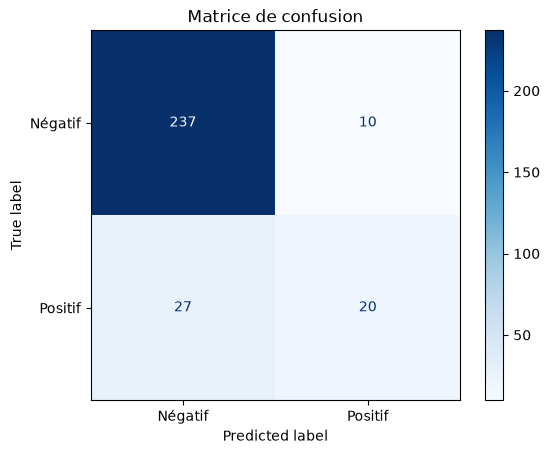

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       247
           1       0.67      0.43      0.52        47

    accuracy                           0.87       294
   macro avg       0.78      0.69      0.72       294
weighted avg       0.86      0.87      0.86       294

AUROC : 0.8376259798432251


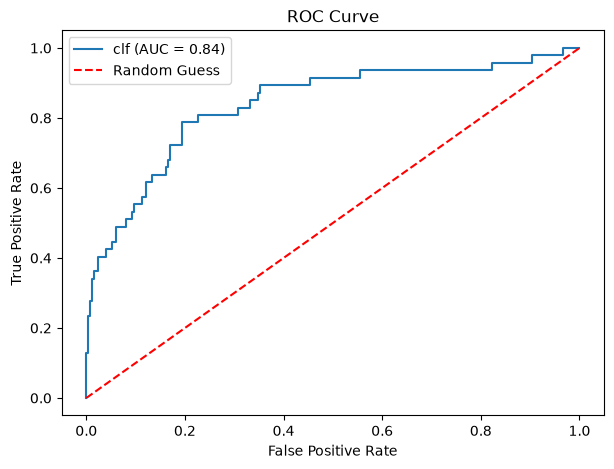

In [669]:
from sklearn.metrics import (roc_auc_score, 
                              confusion_matrix, ConfusionMatrixDisplay, 
                              roc_curve, auc)

y_pred  = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Négatif', 'Positif'])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

print(classification_report(y_test, y_pred))
print("AUROC :", roc_auc_score(y_test, y_proba))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'clf (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Le AUROC est assez haut, la précision est forte, mais vu la séparation des classes, faut mefier.
Rappel - de tous les salaires qui sont partis, qui sont capte par notre modèle ? C'est question nous interesse le plus, et ici on comprend que le rappel pour 1 est bas (43%)

In [670]:
summary_data['0. Logisitic Regression (sans modif)'] = extract_minority_metrics(y_test, y_pred, y_proba)

<span style="font-size: 2.0em; font-weight: bold; color: #ffffff;">🌳 Modèle 2 : Random Forest</span>
<br>

Random Forest = Sklearns construit une centaine d'arbres de décisions - chacun sur une tranche aléatoire de données et de fonctionnalités

### Le processus :

Prenez un arbre de décision fragile, et sur fait une centaine, chacun formé sur un sous-ensemble aléatoire de nos donataires et un sous-ensemble aléatoire de nos fonctionnalités.
Chaque arbre se vote, en fonction de ce qu'il a appris de sa part de données.
Chaque arbre fait sa propre décision.
Nous combinons les prédictions : pour la classification, la réponse finale est la catégorie pour laquelle la plupart des arbres votent (vote majoritaire en prévision)
nous les stockons tous ensemble dans l'objet modèle - la collection d'arbres EST le modèle

### Pourquoi ça marche bien :

En utilisant des données et des fonctionnalités aléatoires pour chaque travail, aide à éviter le surajustement et il fait que la prédiction générale est plus précise et digne de confiance.
Pour la classification, c'est très bien car ca gère les bases des données énormes et ça gère bien les relations non linéaires.

Fonctionnement :

- Échantillonnage bootstrap : des lignes aléatoires sont sélectionnées (avec remise) pour entraîner chaque arbre.

- Sélection aléatoire de caractéristiques : chaque arbre utilise un ensemble aléatoire de caractéristiques (et non toutes les caractéristiques).

- Construction des arbres de décision : les arbres divisent les données en utilisant la meilleure caractéristique de leur ensemble aléatoire. La division se poursuit jusqu'à ce qu'une règle d'arrêt soit atteinte (définie dans les paramètres).

- Prédiction : chaque arbre fournit ses propres prédictions.

- Vote majoritaire : la prédiction finale est celle sur laquelle la plupart des arbres s'accordent.


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.43      0.13      0.20        47

    accuracy                           0.83       294
   macro avg       0.64      0.55      0.55       294
weighted avg       0.79      0.83      0.79       294

AUROC : 0.7805151175811871
Average Precision 0.39715154584125834


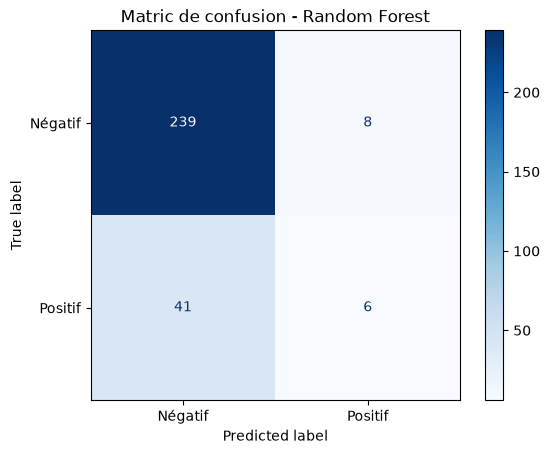

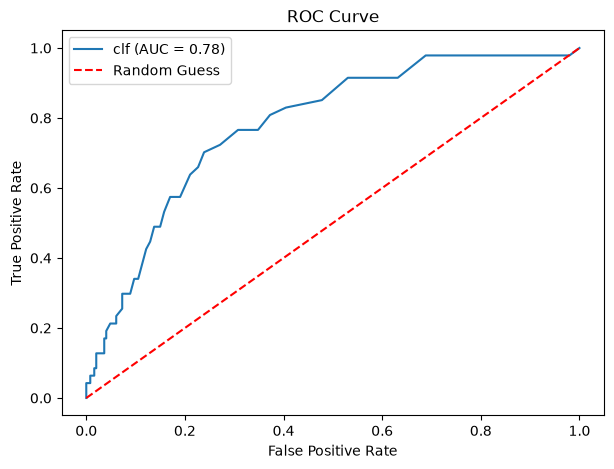


=== Hist Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.58      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.72      0.60      0.62       294
weighted avg       0.82      0.85      0.82       294

AUROC : 0.7880093031268843
Average Precision 0.49424269273711563


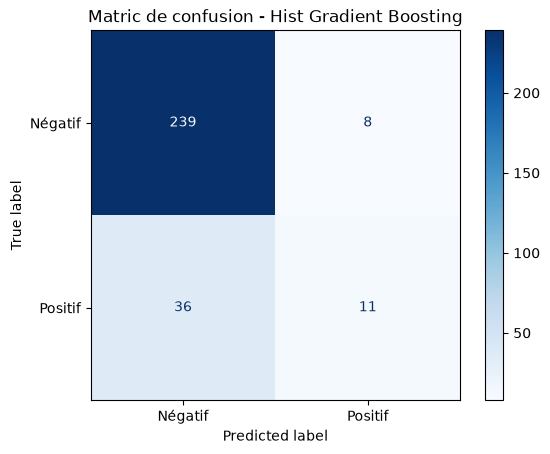

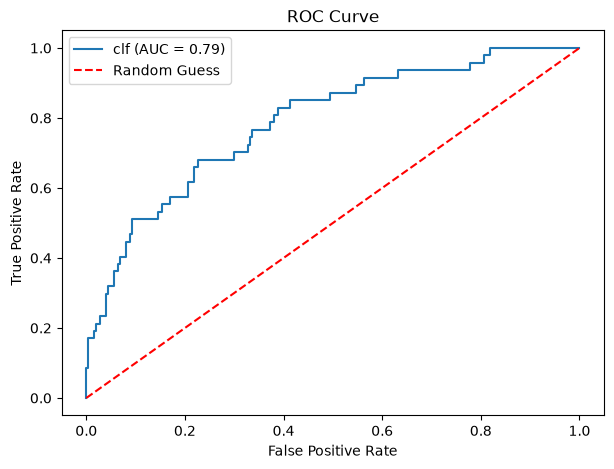

c:\Users\andre\OneDrive\Desktop\Projet3_git\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



=== SVC ===
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294

AUROC : 0.8234128693255234
Average Precision 0.4934511014090189


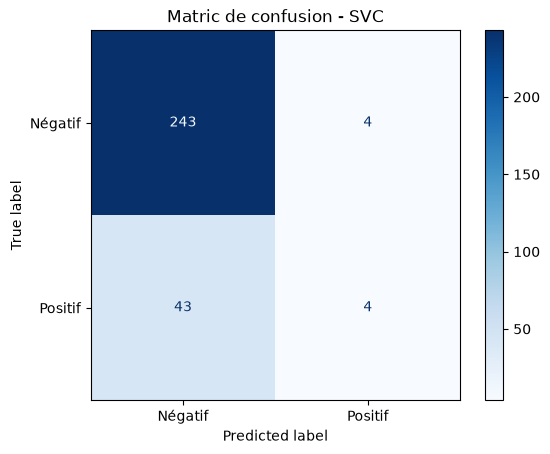

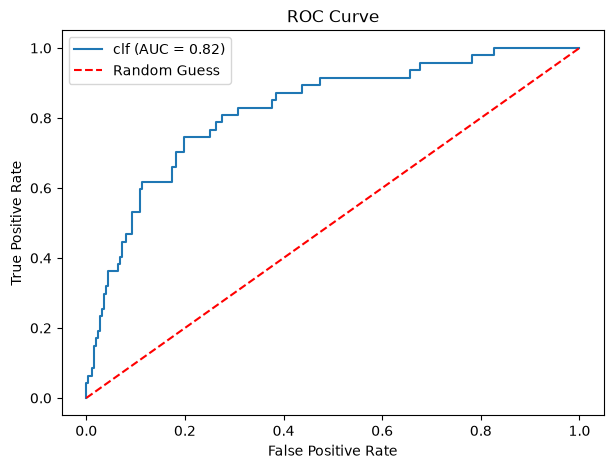

In [671]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score


# For SVC , comme pour LogRef, on utilise X_train_scaled
models = {"Random Forest": RandomForestClassifier(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42), #pas juste Gradient, car on a besoin class_weight, qui n'existe pas dans Gradient
    "SVC": SVC(probability=True, random_state=42),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    print("AUROC :", roc_auc_score(y_test, y_proba))
    print("Average Precision", average_precision_score(y_test, y_proba))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Négatif', 'Positif'])
    disp.plot(cmap="Blues")
    plt.title(f"Matric de confusion - {name}")
    plt.show()
    summary_data[f"{name} (sans modification)"] = extract_minority_metrics(y_test, y_pred, y_proba)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f'clf (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

In [672]:
summary_data

{'0. Logisitic Regression (sans modif)': {'Precision': 0.67,
  'Recall': 0.43,
  'F1-Score': 0.52,
  'AUROC': 0.838,
  'AUPRC (Avg Prec)': 0.614},
 'Random Forest (sans modification)': {'Precision': 0.43,
  'Recall': 0.13,
  'F1-Score': 0.2,
  'AUROC': 0.781,
  'AUPRC (Avg Prec)': 0.397},
 'Hist Gradient Boosting (sans modification)': {'Precision': 0.58,
  'Recall': 0.23,
  'F1-Score': 0.33,
  'AUROC': 0.788,
  'AUPRC (Avg Prec)': 0.494},
 'SVC (sans modification)': {'Precision': 0.5,
  'Recall': 0.09,
  'F1-Score': 0.15,
  'AUROC': 0.823,
  'AUPRC (Avg Prec)': 0.493}}

## Modele 3: Gradient Boosting

Depuis les arbres, on checke la performance de chacun - et au lieu de le jeter, on examine ce qu'on a fait mal - on calcule les résidus - c'est la gap entre ce qu'on a predit et ce qui est vrai et reel.

### Le processus :
ex) Arbre 3 est basé sur les erreurs de tree1 et tree2

Le boosting est un apprentissage séquentiel, la partie dégradée est la direction de l'erreur ("dans quelle direction dois-je aller avec la prédiction pour réduire les erreurs)

## Modele 4: Support Vector Classification (SVC)

On a des points de donnees depuis deux calsses - SVC essaie de trouver la meuilleur line (ou plane) qui les separaent. 
Les donnees qui sont "messy" qui ne peuvent pas etre facilement separaed:
* soft margin : allow some points to be on the wrong side, controlled by paramter C (SVC(C=1.0)); bigger the C, stricter it is 
* kernel trick: if data is not separable in 2D, project it into higher dimensions where it becomes separable.
* class_weight='balanced' dans notre code car on a une imbalance dans nos classes
* probability=True -> pour forcer un output a probabilite afin de computer AUROC

Accuracy : parmi toutes les prédictions, combien étaient correctes ? (TP + TN) / TOTAL
Précision : parmi tout ce que j'avais prédit de positif, combien étaient réellement positifs ? TP/ (TP +FP)

Des remarques concernant : AUROC :
L'accuracy est dominée par la classe majoritaire car TN se situe à la fois au numérateur et au dénominateur
AUROC peut être trompeur avec les classes inéquitables ; c'est mieux que l'accuracy : pour un modèle qui va avoir 247 non-churners et 27 churners, s'il prédit "no churn" pour tout le monde, on va toujours avec 247/274 = 90% de précision.

Problème plus profond : AUROC utilise FPR (FPR = FP / (FP + TN)) sur l'axe des x - si nous avons 247 vrais négatifs, le dénominateur est grand, donc même avec un nombre significatif de faux positifs, nous avons atteint le FPR. La semble courberait bien alors que le modèle peut avoir plein de faux positifs pour le pool beaucoup plus petit de churners réels

Precision (TP/ (TP + FP)) n'a pas un blind spot car le dénominateur est petite ici, et TN n'est pas inclus. En revanche, si on avait l'oppose (CDA une classe majoritaire de gens qui partent - TP - et une classe minoritaire de gens qui restent), on aurait un score de précision à 90% et un rappel (TP / (TP + FN) - de gens qui sont vraiment parties, notre modèle a compris combien ?).

Cela nous indique que les deux, précision et rappel, ne sont pas à l'épreuve des déséquilibres. Pour le corriger, on change pas de formule - on devrait assigner "positive" sur la classe qui est "rare" (minioritaire).

In [673]:
summary_data

{'0. Logisitic Regression (sans modif)': {'Precision': 0.67,
  'Recall': 0.43,
  'F1-Score': 0.52,
  'AUROC': 0.838,
  'AUPRC (Avg Prec)': 0.614},
 'Random Forest (sans modification)': {'Precision': 0.43,
  'Recall': 0.13,
  'F1-Score': 0.2,
  'AUROC': 0.781,
  'AUPRC (Avg Prec)': 0.397},
 'Hist Gradient Boosting (sans modification)': {'Precision': 0.58,
  'Recall': 0.23,
  'F1-Score': 0.33,
  'AUROC': 0.788,
  'AUPRC (Avg Prec)': 0.494},
 'SVC (sans modification)': {'Precision': 0.5,
  'Recall': 0.09,
  'F1-Score': 0.15,
  'AUROC': 0.823,
  'AUPRC (Avg Prec)': 0.493}}

In [674]:
base = pd.DataFrame(summary_data).T
display(base)

,Precision,Recall,F1-Score,AUROC,AUPRC (Avg Prec)
0. Logisitic Regression (sans modif),0.67,0.43,0.52,0.838,0.614
Random Forest (sans modification),0.43,0.13,0.20,0.781,0.397
Hist Gradient Boosting (sans modification),0.58,0.23,0.33,0.788,0.494
SVC (sans modification),0.50,0.09,0.15,0.823,0.493


Sans modification, on comprend que nous ne pouvons pas fier aux donnees liees a la precision, a AUPRC, et a AUROC. 
Ici, Recall est reine car nous voudrons trouver le TN; Logistic Regression est bien meuilleur et en suite Hist GradientBoosting. 

# class_weight='balanced' Solution
On commence par essayer de resoudre le pb des classes inequilibres qui peuvent mettre nos modeles en baisse niveau de la qualite de performance. 

In [675]:
models = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(class_weight='balanced', random_state=42), #pas juste Gradient, car on a besoin class_weight, qui n'existe pas dans Gradient
    "SVC": SVC(class_weight='balanced', probability=True, random_state=42),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    print("AUROC :", roc_auc_score(y_test, y_proba))
    print("Average Precision", average_precision_score(y_test, y_proba))
    cm = confusion_matrix(y_test, y_pred)
    summary_data[f"{name} (class_weight)"] = extract_minority_metrics(y_test, y_pred, y_proba)


=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.94      0.82      0.87       247
           1       0.43      0.72      0.54        47

    accuracy                           0.80       294
   macro avg       0.68      0.77      0.71       294
weighted avg       0.86      0.80      0.82       294

AUROC : 0.8309070548712206
Average Precision 0.5698250106418667

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       247
           1       0.45      0.28      0.34        47

    accuracy                           0.83       294
   macro avg       0.66      0.61      0.62       294
weighted avg       0.80      0.83      0.81       294

AUROC : 0.7467912826255492
Average Precision 0.37297377779107976

=== Hist Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       247
           1       0.52  

c:\Users\andre\OneDrive\Desktop\Projet3_git\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



=== SVC ===
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       247
           1       0.48      0.49      0.48        47

    accuracy                           0.83       294
   macro avg       0.69      0.69      0.69       294
weighted avg       0.83      0.83      0.83       294

AUROC : 0.8266861917477819
Average Precision 0.5410485035253699


In [676]:
base_weights = pd.DataFrame(summary_data).T
display(base_weights)

,Precision,Recall,F1-Score,AUROC,AUPRC (Avg Prec)
0. Logisitic Regression (sans modif),0.67,0.43,0.52,0.838,0.614
Random Forest (sans modification),0.43,0.13,0.20,0.781,0.397
Hist Gradient Boosting (sans modification),0.58,0.23,0.33,0.788,0.494
SVC (sans modification),0.50,0.09,0.15,0.823,0.493
LogisticRegression (class_weight),0.43,0.72,0.54,0.831,0.570
Random Forest (class_weight),0.45,0.28,0.34,0.747,0.373
Hist Gradient Boosting (class_weight),0.52,0.36,0.42,0.774,0.493
SVC (class_weight),0.48,0.49,0.48,0.827,0.541


Logistic regression est toujours bien meuilleur avec un recall de 0.72 (on a presque double en recall score). Les autres grimpent, avec SVC qui est considerablement meuilleur (0.09 -> 0.49). Les AUROCs restent assez stable.

# Génération de données synthétiques
Optimisation : S'en occuper des classes déséquilibrées - un autre facon via SMOTE ; on genere de donnees synthetiques.

Il faut surtout ne pas utiliser SMOTE avant la première division, car cela nous donne la fuite de données.

SMOTE crée les nouveaux points donnés en regardant un point minoritaire et en dessinant une ligne aux voisins les plus proches.

Le but ultime de SMOTE est d'apprendre le modèle comment a reconnaître la classe minoritaire pendant la formation, pour qu'il puisse le déployer dans le monde réel.

Nous ne pouvons pas utiliser "SMOTE" avant le split, car cela rentre dans nos données pour tester.

In [ ]:
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (classification_report, roc_auc_score, 
                              average_precision_score, confusion_matrix, 
                              ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC

# ----------------------------------------------------
# GENERER LA SMOTE DATA (SEULEMENT TRAINING DATA)
# ----------------------------------------------------
# Apply SMOTE to scaled ONLY training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# ----------------------------------------------------
# ON DEFINIT LES MODELES (SANS CLASS_WEIGHT)
# ----------------------------------------------------
# because the data itself is now balanced by SMOTE
smote_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42)
}

# ----------------------------------------------------
# ON LOOP, TRAIN SUR SMOTE, MAIS ON TESTE SUR TESTE
# ----------------------------------------------------
for name, model in smote_models.items():
    # CRITICAL: Train on resampled data (!!!)
    model.fit(X_train_resampled, y_train_resampled)
    
    # CRITICAL: Predict on the ORIGINAL, UNTOUCHED test data
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n==========================================")
    print(f"{name}")
    print(f"==========================================")
    print(classification_report(y_test, y_pred))
    print("AUROC :", roc_auc_score(y_test, y_proba))
    print("Average Precision (PR-AUC):", average_precision_score(y_test, y_proba))
    summary_data[f"{name} (SMOTE)"] = extract_minority_metrics(y_test, y_pred, y_proba)

    # commented out car je pense que ca fait trop dans notebook
    
    # # Confusion matrix
    # cm = confusion_matrix(y_test, y_pred)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negatif', 'Positif'])
    # disp.plot(cmap="Oranges") # Changed color to Oranges to be able to tell SMOTE plots apart from baselines!
    # plt.title(f"Confusion Matrix - {name}")
    # plt.show()

    # # ROC curve
    # fpr, tpr, _ = roc_curve(y_test, y_proba)
    # roc_auc = auc(fpr, tpr)
    
    # plt.figure(figsize=(7, 5))
    # plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', color='darkorange')
    # plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')
    # plt.title(f'ROC Curve - {name}')
    # plt.legend()
    # plt.show()


Logistic Regression (SMOTE)
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       247
           1       0.41      0.66      0.51        47

    accuracy                           0.80       294
   macro avg       0.67      0.74      0.69       294
weighted avg       0.84      0.80      0.81       294

AUROC : 0.8245326901541906
Average Precision (PR-AUC): 0.5672719217291294

Random Forest (SMOTE)
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.52      0.23      0.32        47

    accuracy                           0.84       294
   macro avg       0.70      0.60      0.62       294
weighted avg       0.81      0.84      0.82       294

AUROC : 0.801533293134637
Average Precision (PR-AUC): 0.43212810040836075

Hist Gradient Boosting (SMOTE)
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       247
     

c:\Users\andre\OneDrive\Desktop\Projet3_git\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



SVC (SMOTE)
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       247
           1       0.55      0.38      0.45        47

    accuracy                           0.85       294
   macro avg       0.72      0.66      0.68       294
weighted avg       0.83      0.85      0.84       294

AUROC : 0.8084244982341287
Average Precision (PR-AUC): 0.5053234148648681


In [678]:
base_weights_smote = pd.DataFrame(summary_data).T
display(base_weights_smote)

,Precision,Recall,F1-Score,AUROC,AUPRC (Avg Prec)
0. Logisitic Regression (sans modif),0.67,0.43,0.52,0.838,0.614
Random Forest (sans modification),0.43,0.13,0.20,0.781,0.397
Hist Gradient Boosting (sans modification),0.58,0.23,0.33,0.788,0.494
SVC (sans modification),0.50,0.09,0.15,0.823,0.493
LogisticRegression (class_weight),0.43,0.72,0.54,0.831,0.570
Random Forest (class_weight),0.45,0.28,0.34,0.747,0.373
Hist Gradient Boosting (class_weight),0.52,0.36,0.42,0.774,0.493
SVC (class_weight),0.48,0.49,0.48,0.827,0.541
Logistic Regression (SMOTE) (SMOTE),0.41,0.66,0.51,0.825,0.567
Random Forest (SMOTE) (SMOTE),0.52,0.23,0.32,0.802,0.432


On voit directement que des trois runs, le meuilleur modele est clairement la Logisitic Regression avec un recall la plus haute, avec un AUROC score consistentment plus haute. Il est moins fort en precision, mais cela est moins importante. 

Optimisions donc les deux modeles Logisitic Regression - SMOTE et Class weight pour voir

PR-AUC // la courbe precision recall 
-> compris entre la precision et recall
AUC // courbe auroc

25 juin 
- non linear lol -> SVC
- on va jouer aussi avec done le PR AUC 

# Optimisation via GridSearchCV

Pour la regession logisitique:
- penalty - qu'est qui on punit ?
  si un modele s'overfit, ca veut dire qu'il apprend le training data too well et il apprend ce qui est nois; modele veut faire les coefficients (weights) as large as possible to fit the traiing data perfectly.
  L2: ridge- shrinks all weight toward 0 but never full 0; all features stay in model, just with smaller influence
  L1: lasso - pushes some weights all the way to zero; some features get eliminated; useful when we have a lot of useless columns


- les algos qui existent ("solver")
  liblinear : qui fonctionne bien sur les donnees plus petites, support L1 et L2
  saga : qui marche bien sur les donnees plus larges, also supports L1 et L2
  lbfgs : default , fast, but only supports L2 


In [679]:
from sklearn.model_selection import GridSearchCV


# SMOTE

Pourquoi la pipeline est-elle indispensable ?
La pipeline (imblearn.pipeline) regroupe le scaling, le SMOTE et le modèle dans un seul bloc automatisé. C'est crucial pour 3 raisons :

* Zéro Fuite de Données (Data Leakage) : Elle sert de bouclier. Elle garantit que le scaling et le SMOTE sont calculés uniquement sur l'entraînement. Les données de test restent 100% secrètes, évitant les scores faussement parfaits.

* Un GridSearch parfait : Elle se branche directement dans GridSearchCV. À chaque calcul, elle applique le SMOTE sur les 4 blocs d'entraînement et teste proprement sur le bloc de validation restant.

* Sécurité en production : Le prétraitement et le modèle sont soudés. Quand de nouvelles données réelles arrivent, elles sont transformées automatiquement sans risque d'erreur humaine (et sans appliquer SMOTE sur du réel).

In [680]:
from imblearn.pipeline import Pipeline

tuning_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('log_reg', LogisticRegression(max_iter=2000, random_state=42))
])

param_grid = {
    'log_reg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'log_reg__penalty': ['l2'] # Using l2 as standard. Add 'l1' if solver='liblinear'
}

grid_search = GridSearchCV(
    estimator=tuning_pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='average_precision', # Optimizing for best metric!
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Meuilleurs hyperparametres trouves: {grid_search.best_params_}")
print(f"Best Cross-Validation avg precision: {grid_search.best_score_:.4f}")

Meuilleurs hyperparametres trouves: {'log_reg__C': 0.1, 'log_reg__penalty': 'l2'}
Best Cross-Validation avg precision: 0.6173


c:\Users\andre\OneDrive\Desktop\Projet3_git\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [681]:
results = grid_search.cv_results_
best_index = grid_search.best_index_
fold_scores = [results[f'split{i}_test_score'][best_index] for i in range(5)]
cv_mean, cv_std = np.mean(fold_scores), np.std(fold_scores)

# eval le meilleur sur le test set
best_model = grid_search.best_estimator_

# eval sur le test qui n'est pas touched
y_pred  = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("\n==========================================")
print(" FINAL OPTIMIZED SMOTE MODEL PERFORMANCE")
print("==========================================")
print(classification_report(y_test, y_pred))
print("AUROC :", roc_auc_score(y_test, y_proba))
print("AUPRC test:", average_precision_score(y_test, y_proba))
summary_data["Modele LR SMOTE"] = extract_minority_metrics(y_test, y_pred, y_proba)


 FINAL OPTIMIZED SMOTE MODEL PERFORMANCE
              precision    recall  f1-score   support

           0       0.93      0.81      0.87       247
           1       0.41      0.70      0.52        47

    accuracy                           0.79       294
   macro avg       0.67      0.75      0.69       294
weighted avg       0.85      0.79      0.81       294

AUROC : 0.8334051167197863
AUPRC test: 0.5904413174507644


# POUR CLASS WEIGHTS 

In [682]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100], # try different regularization strengths (C) and penalty types
    'penalty': ['l2']
}

lr_weighted = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

grid_weighted = GridSearchCV(
    estimator=lr_weighted,
    param_grid=param_grid,
    cv=5,
    scoring='average_precision',
    n_jobs=-1
)

grid_weighted.fit(X_train_scaled, y_train)

print("Meuilleurs parametres pour Logistic Regression, class_weighed", grid_weighted.best_params_)

results = grid_weighted.cv_results_
best_index = grid_weighted.best_index_
fold_scores = [results[f'split{i}_test_score'][best_index] for i in range(5)]
cv_mean, cv_std = np.mean(fold_scores), np.std(fold_scores)

best_model_cw = grid_weighted.best_estimator_

y_pred_cw = best_model_cw.predict(X_test_scaled)
y_proba_cw = best_model_cw.predict_proba(X_test_scaled)[:, 1]

print("\n==========================================")
print(" FINAL OPTIMIZED CLASS WEIGHTED MODEL PERFORMANCE")
print("==========================================")
print(classification_report(y_test, y_pred_cw))
print("AUROC :", roc_auc_score(y_test, y_proba_cw))
print("AUPRC test:", average_precision_score(y_test, y_proba_cw))
summary_data["Opti, meuiller LR modele CW"] = extract_minority_metrics(y_test, y_pred_cw, y_proba_cw)

Meuilleurs parametres pour Logistic Regression, class_weighed {'C': 0.01, 'penalty': 'l2'}

 FINAL OPTIMIZED CLASS WEIGHTED MODEL PERFORMANCE
              precision    recall  f1-score   support

           0       0.95      0.78      0.85       247
           1       0.40      0.77      0.52        47

    accuracy                           0.78       294
   macro avg       0.67      0.77      0.69       294
weighted avg       0.86      0.78      0.80       294

AUROC : 0.8315100353174262
AUPRC test: 0.5517761053198701


c:\Users\andre\OneDrive\Desktop\Projet3_git\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [683]:
all = pd.DataFrame(summary_data).T
display(all)

,Precision,Recall,F1-Score,AUROC,AUPRC (Avg Prec)
0. Logisitic Regression (sans modif),0.67,0.43,0.52,0.838,0.614
Random Forest (sans modification),0.43,0.13,0.20,0.781,0.397
Hist Gradient Boosting (sans modification),0.58,0.23,0.33,0.788,0.494
SVC (sans modification),0.50,0.09,0.15,0.823,0.493
LogisticRegression (class_weight),0.43,0.72,0.54,0.831,0.570
Random Forest (class_weight),0.45,0.28,0.34,0.747,0.373
Hist Gradient Boosting (class_weight),0.52,0.36,0.42,0.774,0.493
SVC (class_weight),0.48,0.49,0.48,0.827,0.541
Logistic Regression (SMOTE) (SMOTE),0.41,0.66,0.51,0.825,0.567
Random Forest (SMOTE) (SMOTE),0.52,0.23,0.32,0.802,0.432


En regardant nos resultats finales, nous comprendre que le meuilleur modele pour notre use case est la Logistic Regression avec les class_weight='balanced'; un recall le plus performant de tous a 0.77, un F! score qui est parmi les tops (0.52). et un AUPRC a 0.552. 

## Precision-Recall (PR) Curve

Maintenant que nous avons notre modele qui est opti et le meuilleur dans notre cas, nous pouvons aller plus loin :
* essayons de trouver un seuil qui est mieux. 

Avec un seuil trop haut, on risque de ne pas pouvoir capter tout, et avec un seuil trop bas, on risque de tout capter sans discrimination.
Notre seuil, qui est a 0.50 par defaut, devrait etre a 0.56

Standard Threshold: 0.50
Mathematically Optimal Threshold: 0.5664


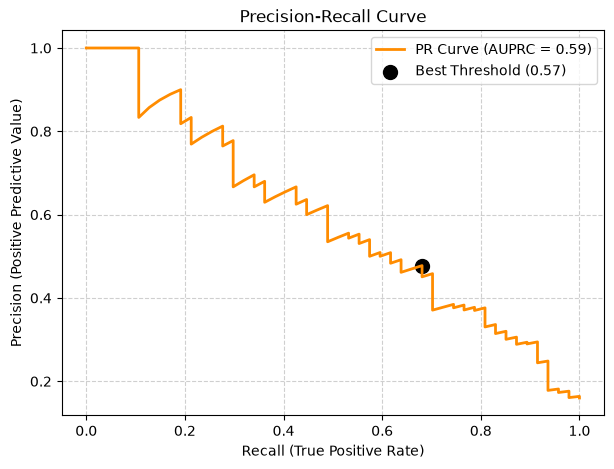

In [684]:
# Pour ne pas rester avec que le 0.5 threshold ; trouvons un qui est better:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# find the optimal threshold that maximizes the F1-score
# (F1 = 2 * (Precision * Recall) / (Precision + Recall))
#1e-10 to not diviser par 0 
f_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_index = np.argmax(f_scores)
best_threshold = thresholds[best_index]

print(f"Standard Threshold: 0.50")
print(f"Mathematically Optimal Threshold: {best_threshold:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color='darkorange', lw=2, label=f'PR Curve (AUPRC = {average_precision_score(y_test, y_proba):.2f})')
plt.scatter(recalls[best_index], precisions[best_index], color='black', marker='o', s=100, label=f'Best Threshold ({best_threshold:.2f})')

plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [685]:
custom_preds = (y_proba_cw >= best_threshold).astype(int)

print(f"==========================================")
print(f" PERFORMANCE WITH CUSTOM THRESHOLD ({best_threshold:.2f})")
print(f"==========================================")
print(classification_report(y_test, custom_preds))
summary_data["Modele gagnante avec PR seuil"] = extract_minority_metrics(y_test, y_pred_cw, y_proba_cw)

 PERFORMANCE WITH CUSTOM THRESHOLD (0.57)
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       247
           1       0.44      0.64      0.52        47

    accuracy                           0.81       294
   macro avg       0.68      0.74      0.70       294
weighted avg       0.85      0.81      0.83       294



In [686]:
df_resultats = pd.DataFrame(summary_data).T
display(df_resultats)

,Precision,Recall,F1-Score,AUROC,AUPRC (Avg Prec)
0. Logisitic Regression (sans modif),0.67,0.43,0.52,0.838,0.614
Random Forest (sans modification),0.43,0.13,0.20,0.781,0.397
Hist Gradient Boosting (sans modification),0.58,0.23,0.33,0.788,0.494
SVC (sans modification),0.50,0.09,0.15,0.823,0.493
LogisticRegression (class_weight),0.43,0.72,0.54,0.831,0.570
Random Forest (class_weight),0.45,0.28,0.34,0.747,0.373
Hist Gradient Boosting (class_weight),0.52,0.36,0.42,0.774,0.493
SVC (class_weight),0.48,0.49,0.48,0.827,0.541
Logistic Regression (SMOTE) (SMOTE),0.41,0.66,0.51,0.825,0.567
Random Forest (SMOTE) (SMOTE),0.52,0.23,0.32,0.802,0.432


# Feature Importance / Coefficients

In [693]:
coefficients = best_model_cw.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns if hasattr(X_train_scaled, 'columns') else X.columns, 
    'Coefficient': coefficients
})

feature_importance['Absolute_Impact'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Impact', ascending=False).drop(columns=['Absolute_Impact'])

print("=====================================================")
print(" FEATURE IMPORTANCE (LOGISTIC REGRESSION COEFFICIENTS)")
print("=====================================================")
feature_importance.head(10)

 FEATURE IMPORTANCE (LOGISTIC REGRESSION COEFFICIENTS)


,Feature,Coefficient
64,heure_supplementaires_Oui,0.442832
42,frequence_deplacement_Frequent,0.257672
26,poste_Consultant,0.247357
19,aucune_participation_pee,0.235797
50,niveau_hierarchique_poste_2,-0.222382
56,satisfaction_employee_nature_travail_4,-0.213771
46,satisfaction_employee_environnement_4,-0.206888
2,nombre_experiences_precedentes,0.203677
61,satisfaction_employee_equilibre_pro_perso_3,-0.199278
16,stagnation_poste,-0.188473


Au finale, nous comprendrons que les raisons les plus probables de faire quitter l'entreprise sont:
* si les salaires travaillents les heures supplementaires - 0.44
* si les salaires devraient se deplacer frequentement - 0.25
* si leur poste est celui de Consultant - 0.24
* si ils ne participent pas au PEE - 0.23